In [1]:
# !pip install PyTDC

### Check out the Data

In [2]:
from tdc.single_pred import ADME

In [3]:
data = ADME(name = 'BBB_Martins')
split = data.get_split()

Found local copy...
Loading...
Done!


In [4]:
split.keys()

dict_keys(['train', 'valid', 'test'])

In [5]:
split['train']

,Drug_ID,Drug,Y
0,Terbutylchlorambucil,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,1
1,40730,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,1
2,cloxacillin,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,1
3,cefoperazone,CCN1CCN(C(=O)N[C@@H](C(=O)N[C@@H]2C(=O)N3C(C(=...,1
4,rolitetracycline,CN(C)[C@@H]1C(=O)/C(=C(/O)NCN2CCCC2)C(=O)[C@@]...,1
...,...,...,...
1416,licostinel,O=c1[nH]c2cc(Cl)c(Cl)c([N+](=O)[O-])c2[nH]c1=O,1
1417,ademetionine(adenosyl-methionine),C[S+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2cnc...,1
1418,mesocarb,CC(Cc1ccccc1)n1cc([N-]C(=O)Nc2ccccc2)[o+]n1,1
1419,tofisoline,CCc1c(C)[n+]([NH-])c(-c2ccc(OC)c(OC)c2)c2cc(OC...,1


In [6]:
split['train']['Y'].value_counts(dropna=False)

Y
1    1096
0     325
Name: count, dtype: int64

In [7]:
split['valid']

,Drug_ID,Drug,Y
0,timiperone,O=C(CCCN1CCC(n2c(=S)[nH]c3ccccc32)CC1)c1ccc(F)cc1,1
1,compound 32,O=[N+]([O-])C1=CC=NC1NCCSCc1ccccn1,1
2,ketorfanol,O=C1CC[C@H]2[C@H]3Cc4cccc(O)c4[C@@]2(CCN3CC2CC...,1
3,phenytoin,O=C1NC(=O)C(c2ccccc2)(c2ccccc2)N1,1
4,fluocortin,CCCCOC(=O)C(=O)C1C(C)CC2C3CC(F)C4=CC(=O)C=CC4(...,1
...,...,...,...
198,sibopirdine,O.c1cncc(CC2(Cc3ccncc3)c3cccnc3-c3ncccc32)c1,1
199,Sulfadiazine,Nc1ccc(S(=O)(=O)Nc2ncccn2)cc1,1
200,2-methylpropanol,CC(C)CO,1
201,thialbarbital,C=CCC1(C2C=CCCC2)C(=O)NC(=S)NC1=O,1


In [8]:
split['valid']['Y'].value_counts(dropna=False)

Y
1    152
0     51
Name: count, dtype: int64

In [9]:
split['test']

,Drug_ID,Drug,Y
0,mevastatin,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1
1,anseculin,COc1cc2oc(=O)c(C)c(C)c2cc1OCCCN1CCN(c2ccccc2OC...,1
2,moxalactam,CO[C@@]1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C...,0
3,taclamine,c1ccc2c(c1)CCc1cccc3c1C2CN1CCCCC31,1
4,indriline,CN(C)CCC1(c2ccccc2)C=Cc2ccccc21,1
...,...,...,...
401,rifamide,CCN(CC)C(=O)COc1cc2c(O)c3c(O)c(C)c4c(c13)C(=O)...,0
402,BRL52871,O=C(Cc1ccc(Cl)c(Cl)c1)N1CCc2sccc2[C@H]1CN1CCCC1,1
403,hydromorphone,CN1CC[C@]23c4c5ccc(O)c4O[C@H]2C(=O)CC[C@H]3[C@...,1
404,suritozole,Cn1nc(-c2cccc(F)c2)n(C)c1=S,1


In [10]:
split['test']['Y'].value_counts(dropna=False)

Y
1    303
0    103
Name: count, dtype: int64

### Train and Evaluate Logistic Regression Model

SMILES → Morgan fingerprints → Logistic regression → BBB prediction

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tdc.single_pred import ADME

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

In [12]:
data = ADME(name="BBB_Martins")
split = data.get_split()

train_df = split["train"].copy()
valid_df = split["valid"].copy()
test_df = split["test"].copy()

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test: ", test_df.shape)

train_df.head()

Found local copy...
Loading...
Done!


Train: (1421, 3)
Valid: (203, 3)
Test:  (406, 3)


,Drug_ID,Drug,Y
0,Terbutylchlorambucil,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,1
1,40730,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,1
2,cloxacillin,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,1
3,cefoperazone,CCN1CCN(C(=O)N[C@@H](C(=O)N[C@@H]2C(=O)N3C(C(=...,1
4,rolitetracycline,CN(C)[C@@H]1C(=O)/C(=C(/O)NCN2CCCC2)C(=O)[C@@]...,1


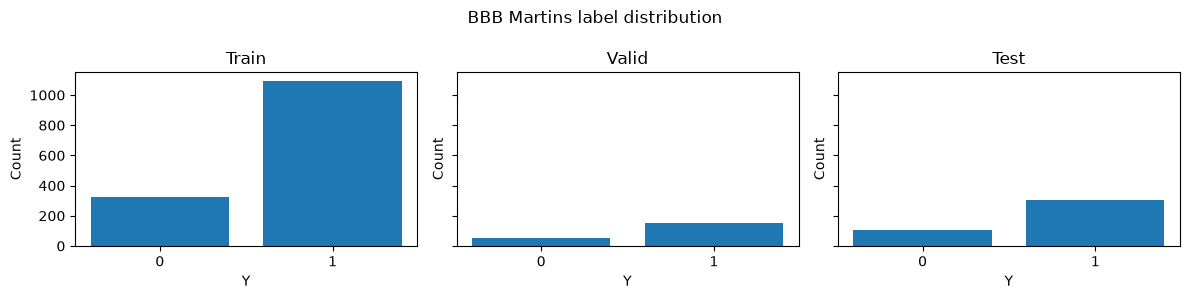

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for ax, df, name in zip(
    axes,
    [train_df, valid_df, test_df],
    ["Train", "Valid", "Test"]
):
    counts = df["Y"].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(name)
    ax.set_xlabel("Y")
    ax.set_ylabel("Count")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["0", "1"])

plt.suptitle("BBB Martins label distribution")
plt.tight_layout()
plt.show()

In [14]:
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFingerprintGenerator

RDLogger.DisableLog("rdApp.warning")

FP_SIZE = 2048

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=FP_SIZE
)

def smiles_to_morgan_fp(smiles, fp_size=FP_SIZE):
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return np.zeros(fp_size, dtype=np.int8), False
    
    fp = morgan_generator.GetFingerprint(mol)
    arr = np.zeros((fp_size,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr, True


def dataframe_to_features(df):
    fps = []
    valid_smiles = []
    
    for smiles in df["Drug"]:
        fp, ok = smiles_to_morgan_fp(smiles)
        fps.append(fp)
        valid_smiles.append(ok)
    
    X = np.vstack(fps)
    y = df["Y"].astype(int).values
    
    return X, y, np.array(valid_smiles)


X_train, y_train, train_valid_smiles = dataframe_to_features(train_df)
X_valid, y_valid, valid_valid_smiles = dataframe_to_features(valid_df)
X_test, y_test, test_valid_smiles = dataframe_to_features(test_df)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test: ", X_test.shape)

print()
print("Invalid train SMILES:", (~train_valid_smiles).sum())
print("Invalid valid SMILES:", (~valid_valid_smiles).sum())
print("Invalid test SMILES: ", (~test_valid_smiles).sum())

X_train: (1421, 2048)
X_valid: (203, 2048)
X_test:  (406, 2048)

Invalid train SMILES: 0
Invalid valid SMILES: 0
Invalid test SMILES:  0


In [15]:
candidate_C_values = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 33, 100]

valid_results = []

for C in candidate_C_values:
    model = LogisticRegression(
        C=C,
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=0,
    )
    
    model.fit(X_train, y_train)
    
    valid_probs = model.predict_proba(X_valid)[:, 1]
    valid_preds = (valid_probs >= 0.5).astype(int)
    
    result = {
        "C": C,
        "valid_roc_auc": roc_auc_score(y_valid, valid_probs),
        "valid_pr_auc": average_precision_score(y_valid, valid_probs),
        "valid_accuracy": accuracy_score(y_valid, valid_preds),
        "valid_balanced_accuracy": balanced_accuracy_score(y_valid, valid_preds),
        "valid_f1": f1_score(y_valid, valid_preds),
    }
    
    valid_results.append(result)

valid_results_df = pd.DataFrame(valid_results)
valid_results_df


,C,valid_roc_auc,valid_pr_auc,valid_accuracy,valid_balanced_accuracy,valid_f1
0,0.0001,0.869840,0.943463,0.527094,0.664667,0.551402
1,0.0003,0.873323,0.945365,0.669951,0.753547,0.726531
2,0.0010,0.881063,0.949427,0.778325,0.767286,0.842105
3,0.0030,0.895511,0.955519,0.807882,0.773994,0.867797
4,0.0100,0.910604,0.962711,0.827586,0.774123,0.884488
5,0.0300,0.918215,0.966232,0.852217,0.797085,0.901961
6,0.1000,0.917054,0.965681,0.876847,0.826561,0.918567
7,0.3000,0.909443,0.962841,0.871921,0.823271,0.915033
8,1.0000,0.898091,0.958418,0.876847,0.820046,0.919094
9,3.0000,0.887642,0.953573,0.857143,0.787345,0.906752


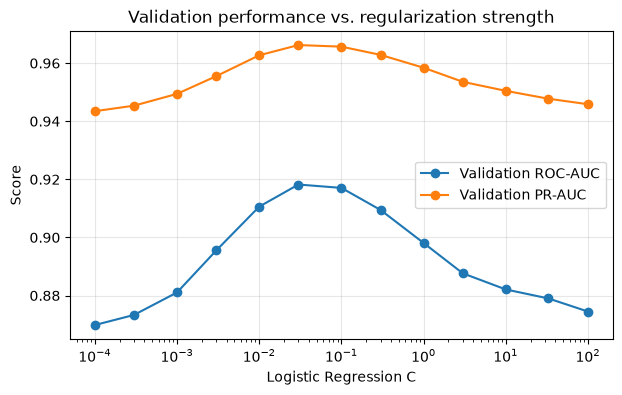

In [16]:
plt.figure(figsize=(7, 4))

plt.plot(
    valid_results_df["C"],
    valid_results_df["valid_roc_auc"],
    marker="o",
    label="Validation ROC-AUC",
)

plt.plot(
    valid_results_df["C"],
    valid_results_df["valid_pr_auc"],
    marker="o",
    label="Validation PR-AUC",
)

plt.xscale("log")
plt.xlabel("Logistic Regression C")
plt.ylabel("Score")
plt.title("Validation performance vs. regularization strength")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [17]:
best_row = valid_results_df.sort_values("valid_roc_auc", ascending=False).iloc[0]
best_C = best_row["C"]

print("Best C:", best_C)
best_row

Best C: 0.03


C                          0.030000
valid_roc_auc              0.918215
valid_pr_auc               0.966232
valid_accuracy             0.852217
valid_balanced_accuracy    0.797085
valid_f1                   0.901961
Name: 5, dtype: float64

In [18]:
X_train_valid = np.vstack([X_train, X_valid])
y_train_valid = np.concatenate([y_train, y_valid])

final_model = LogisticRegression(
    C=best_C,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=0,
)

final_model.fit(X_train_valid, y_train_valid)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.03
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penaltie

In [19]:
test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

test_metrics = {
    "ROC-AUC": roc_auc_score(y_test, test_probs),
    "PR-AUC": average_precision_score(y_test, test_probs),
    "Accuracy": accuracy_score(y_test, test_preds),
    "Balanced Accuracy": balanced_accuracy_score(y_test, test_preds),
    "Precision": precision_score(y_test, test_preds),
    "Recall": recall_score(y_test, test_preds),
    "F1": f1_score(y_test, test_preds),
}

pd.Series(test_metrics).to_frame("Test score")

,Test score
ROC-AUC,0.892451
PR-AUC,0.955956
Accuracy,0.849754
Balanced Accuracy,0.790397
Precision,0.890323
Recall,0.910891
F1,0.900489


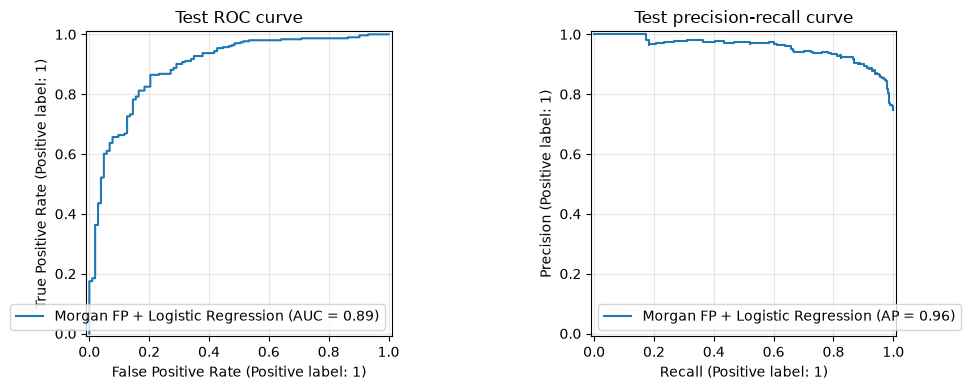

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

RocCurveDisplay.from_predictions(
    y_test,
    test_probs,
    ax=axes[0],
    name="Morgan FP + Logistic Regression",
)
axes[0].set_title("Test ROC curve")
axes[0].grid(True, alpha=0.3)

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probs,
    ax=axes[1],
    name="Morgan FP + Logistic Regression",
)
axes[1].set_title("Test precision-recall curve")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

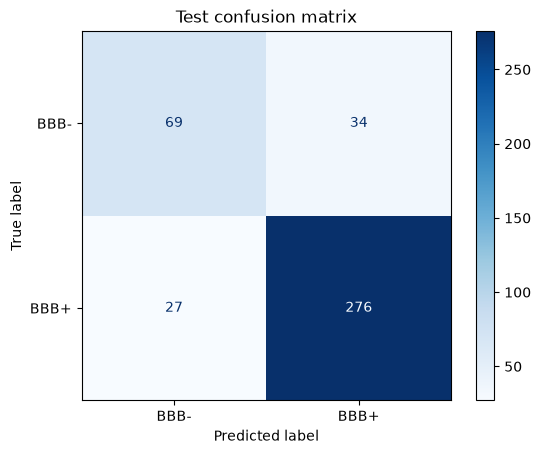

In [21]:
cm = confusion_matrix(y_test, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BBB-", "BBB+"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Test confusion matrix")
plt.show()

In [22]:
test_predictions_df = test_df.copy()
test_predictions_df["predicted_probability_BBB_positive"] = test_probs
test_predictions_df["predicted_label"] = test_preds
test_predictions_df["correct"] = test_predictions_df["Y"] == test_predictions_df["predicted_label"]

test_predictions_df.head()

,Drug_ID,Drug,Y,predicted_probability_BBB_positive,predicted_label,correct
0,mevastatin,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1,0.473552,0,False
1,anseculin,COc1cc2oc(=O)c(C)c(C)c2cc1OCCCN1CCN(c2ccccc2OC...,1,0.869365,1,True
2,moxalactam,CO[C@@]1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C...,0,0.103473,0,True
3,taclamine,c1ccc2c(c1)CCc1cccc3c1C2CN1CCCCC31,1,0.911437,1,True
4,indriline,CN(C)CCC1(c2ccccc2)C=Cc2ccccc21,1,0.905085,1,True


In [23]:
test_predictions_df.sort_values(
    "predicted_probability_BBB_positive",
    ascending=False
).head(10)[
    ["Drug_ID", "Drug", "Y", "predicted_probability_BBB_positive", "predicted_label", "correct"]
]

,Drug_ID,Drug,Y,predicted_probability_BBB_positive,predicted_label,correct
91,trifluoperazine,CN1CCN(CCCN2c3ccccc3Sc3ccc(C(F)(F)F)cc32)CC1,1,0.974330,1,True
137,fludiazepam,CN1C(=O)CN=C(c2ccccc2F)c2cc(Cl)ccc21,1,0.962108,1,True
290,thiethylperazine,CCSc1ccc2c(c1)N(CCCN1CCN(C)CC1)c1ccccc1S2,1,0.961887,1,True
270,iclazepam,O=C1CN=C(c2ccccc2)c2cc(Cl)ccc2N1CCOCC1CC1,1,0.955123,1,True
172,thioproperazine,CN1CCN(CCCN2c3ccccc3Sc3ccc(S(=O)(=O)N(C)C)cc32...,1,0.954426,1,True
203,difluprednate,CCCC(=O)O[C@]1(C(=O)COC(C)=O)CC[C@H]2[C@@H]3C[...,1,0.948623,1,True
227,clazolam,CN1C(=O)CN2CCc3ccccc3C2c2cc(Cl)ccc21,1,0.947575,1,True
132,fluanisone,COc1ccccc1N1CCN(CCCC(=O)c2ccc(F)cc2)CC1,1,0.946877,1,True
253,thiothixene,CN1CCN(CC/C=C2\c3ccccc3Sc3ccc(S(=O)(=O)N(C)C)c...,1,0.946855,1,True
149,methopromazine,COc1ccc2c(c1)N(CCCN(C)C)c1ccccc1S2,1,0.945503,1,True


In [24]:
test_predictions_df.sort_values(
    "predicted_probability_BBB_positive",
    ascending=True
).head(10)[
    ["Drug_ID", "Drug", "Y", "predicted_probability_BBB_positive", "predicted_label", "correct"]
]

,Drug_ID,Drug,Y,predicted_probability_BBB_positive,predicted_label,correct
357,cefatrizine,NC(C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(CSc3cn[nH]n...,0,0.022356,0,True
146,sulbenicillin,CC1(C)S[C@@H]2[C@H](NC(=O)C(c3ccccc3)S(=O)(=O)...,0,0.029224,0,True
283,cefuzonam,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(CSc3cn...,0,0.038684,0,True
295,arbekacin,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,0,0.044314,0,True
192,pivampicillin,CC(C)(C)C(=O)OCOC(=O)[C@@H]1N2C(=O)[C@@H](NC(=...,0,0.052855,0,True
142,roxithromycin,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,0,0.053756,0,True
259,carindacillin,CC1(C)S[C@@H]2[C@H](NC(=O)C(C(=O)Oc3ccc4c(c3)C...,0,0.053961,0,True
154,Ticarcillin,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](C(=O)[O-])c3cc...,1,0.057489,0,False
219,ceftiolene,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(/C=C/S...,0,0.063825,0,True
97,erythromycin,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,0,0.066392,0,True


In [25]:
test_predictions_df['predicted_probability_BBB_positive'].describe()

count    406.000000
mean       0.645908
std        0.248197
min        0.022356
25%        0.514267
50%        0.706421
75%        0.848158
max        0.974330
Name: predicted_probability_BBB_positive, dtype: float64

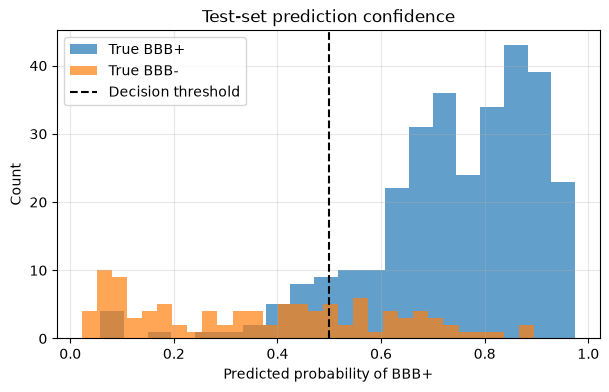

In [26]:
plt.figure(figsize=(7, 4))


plt.hist(
    test_predictions_df.loc[test_predictions_df["Y"] == 1, "predicted_probability_BBB_positive"],
    bins=20,
    alpha=0.7,
    label="True BBB+",
)

plt.hist(
    test_predictions_df.loc[test_predictions_df["Y"] == 0, "predicted_probability_BBB_positive"],
    bins=30,
    alpha=0.7,
    label="True BBB-",
)

plt.axvline(0.5, color="black", linestyle="--", label="Decision threshold")

plt.xlabel("Predicted probability of BBB+")
plt.ylabel("Count")
plt.title("Test-set prediction confidence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
# test_predictions_df.to_csv("bbb_martins_test_predictions.csv", index=False)

# print("Saved predictions to bbb_martins_test_predictions.csv")

#### Train Graph Neural Network on SMILES for Blood-Brain Barrier (BBB) permiability

In [165]:
from rdkit import Chem
import torch
from torch_geometric.data import Data

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    # Extract node (atom) features
    node_features = []
    for atom in mol.GetAtoms():
        node_features.append([atom.GetAtomicNum(), atom.GetDegree()])
    x = torch.tensor(node_features, dtype=torch.float)
    
    # Extract edge (bond) indices
    edge_indices = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_indices += [[i, j], [j, i]]  # Undirected graph
        
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index)

In [166]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class MolecularGNN(nn.Module):
    def __init__(self, num_node_features, hidden_dim, output_dim):
        super(MolecularGNN, self).__init__()
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.linear = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index, batch):
        # Message passing / Graph convolutions
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        # Readout / Pooling to get 1 vector per molecule
        x = global_mean_pool(x, batch)
        
        return self.linear(x)


In [167]:
from torch_geometric.loader import DataLoader

# Setup data, model, optimizer, and loss
dataset = list(zip([smiles_to_graph(mol) for mol in df["Drug"]], list(torch.tensor(df["Y"].astype(int).values))))
loader = DataLoader(dataset, batch_size=32, shuffle=True)
model = MolecularGNN(num_node_features=2, hidden_dim=64, output_dim=1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

model.train()
for epoch in range(30):
    for batch_input, batch_output in loader:
        # batch_input, batch_output = batch
        optimizer.zero_grad()
        pred = model(batch_input.x, batch_input.edge_index, batch_input.batch)
        # Assume batch_output holds your target molecular property tensor
        loss = criterion(pred.squeeze(), batch_output)
        loss.backward()
        optimizer.step()


In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Draw, AllChem, DataStructs

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
from sklearn.decomposition import PCA

import networkx as nx
from IPython.display import display

In [169]:
df.head()


,Drug_ID,Drug,Y
0,mevastatin,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1
1,anseculin,COc1cc2oc(=O)c(C)c(C)c2cc1OCCCN1CCN(c2ccccc2OC...,1
2,moxalactam,CO[C@@]1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C...,0
3,taclamine,c1ccc2c(c1)CCc1cccc3c1C2CN1CCCCC31,1
4,indriline,CN(C)CCC1(c2ccccc2)C=Cc2ccccc21,1


In [170]:
df

,Drug_ID,Drug,Y
0,mevastatin,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1
1,anseculin,COc1cc2oc(=O)c(C)c(C)c2cc1OCCCN1CCN(c2ccccc2OC...,1
2,moxalactam,CO[C@@]1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C...,0
3,taclamine,c1ccc2c(c1)CCc1cccc3c1C2CN1CCCCC31,1
4,indriline,CN(C)CCC1(c2ccccc2)C=Cc2ccccc21,1
...,...,...,...
401,rifamide,CCN(CC)C(=O)COc1cc2c(O)c3c(O)c(C)c4c(c13)C(=O)...,0
402,BRL52871,O=C(Cc1ccc(Cl)c(Cl)c1)N1CCc2sccc2[C@H]1CN1CCCC1,1
403,hydromorphone,CN1CC[C@]23c4c5ccc(O)c4O[C@H]2C(=O)CC[C@H]3[C@...,1
404,suritozole,Cn1nc(-c2cccc(F)c2)n(C)c1=S,1


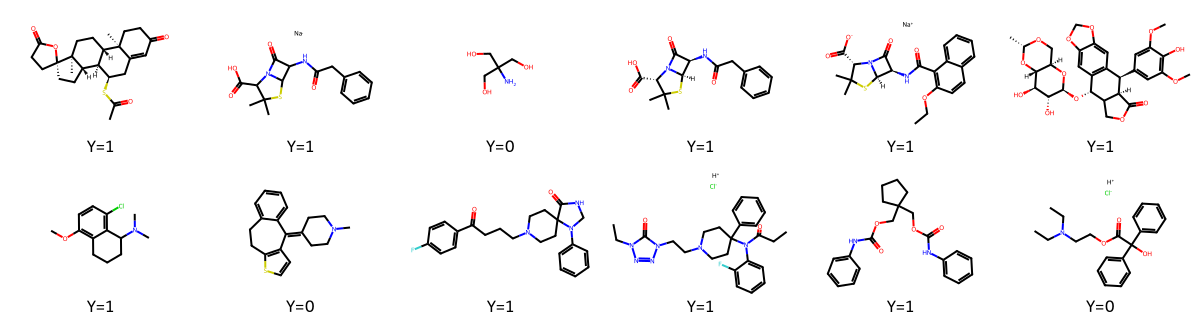

In [171]:
sample_df = (
    df.groupby("Y", group_keys=False)
      .apply(lambda g: g.sample(min(len(g), 6), random_state=42))
)

mols = [Chem.MolFromSmiles(smi) for smi in sample_df["Drug"]]
legends = [f"Y={y}" for y in df["Y"]]

display(
    Draw.MolsToGridImage(
        mols,
        molsPerRow=6,
        subImgSize=(200, 160),
        legends=legends
    )
)

In [172]:
ATOM_TYPES = [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]  
# H, C, N, O, F, P, S, Cl, Br, I

DEGREES = [0, 1, 2, 3, 4, 5]


def one_hot_with_unknown(value, choices):
    """
    One-hot encode value.
    If value is not in choices, all zeros are used.
    """
    return [int(value == choice) for choice in choices]


def atom_features(atom):
    atomic_num = atom.GetAtomicNum()
    degree = atom.GetDegree()
    formal_charge = atom.GetFormalCharge()
    is_aromatic = int(atom.GetIsAromatic())

    features = []
    features += one_hot_with_unknown(atomic_num, ATOM_TYPES)
    features += one_hot_with_unknown(degree, DEGREES)
    features += [formal_charge]
    features += [is_aromatic]

    return features


def smiles_to_graph(smiles, y=None):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    node_features = []
    for atom in mol.GetAtoms():
        node_features.append(atom_features(atom))

    x = torch.tensor(node_features, dtype=torch.float)

    edge_indices = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Add both directions because molecular bonds are undirected.
        edge_indices += [[i, j], [j, i]]

    if len(edge_indices) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()

    data = Data(x=x, edge_index=edge_index)

    if y is not None:
        data.y = torch.tensor([float(y)], dtype=torch.float)

    data.smiles = smiles

    return data

In [173]:
data_list = []
valid_rows = []

for _, row in df.iterrows():
    data = smiles_to_graph(row["Drug"], row["Y"])
    if data is not None:
        data_list.append(data)
        valid_rows.append(row)

valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)

print(f"Original rows: {len(df)}")
print(f"Valid molecules: {len(data_list)}")
print(f"Number of node features: {data_list[0].x.shape[1]}")

Original rows: 406
Valid molecules: 406
Number of node features: 18


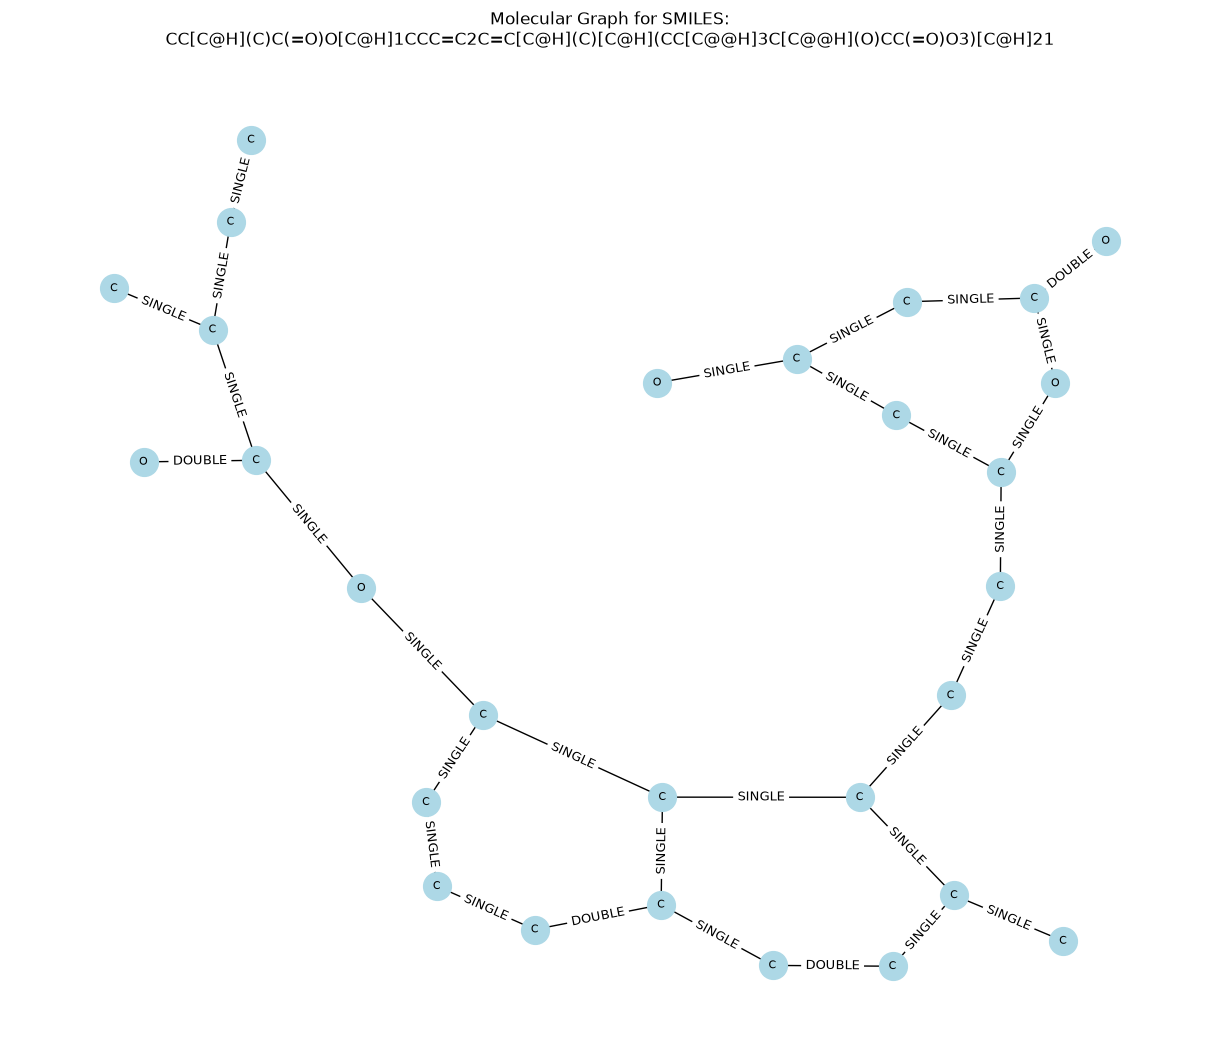

In [174]:
def plot_molecule_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)

    G = nx.Graph()

    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        label = atom.GetSymbol()
        G.add_node(idx, label=label)

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_type = str(bond.GetBondType())
        G.add_edge(i, j, label=bond_type)

    pos = nx.spring_layout(G, seed=42)

    node_labels = nx.get_node_attributes(G, "label")
    edge_labels = nx.get_edge_attributes(G, "label")

    plt.figure(figsize=(12, 10))
    nx.draw(
        G,
        pos,
        labels=node_labels,
        with_labels=True,
        node_size=400,
        node_color="lightblue",
        font_size=8
    )
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
    plt.title(f"Molecular Graph for SMILES:\n{smiles}")
    plt.axis("off")
    plt.show()


example_smiles = valid_df.iloc[0]["Drug"]
plot_molecule_graph(example_smiles)

In [175]:
labels = valid_df["Y"].astype(int).values
indices = np.arange(len(data_list))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.2,
    random_state=42,
    stratify=labels[train_idx]
)

train_data = [data_list[i] for i in train_idx]
val_data = [data_list[i] for i in val_idx]
test_data = [data_list[i] for i in test_idx]

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train: {len(train_data)}")
print(f"Validation: {len(val_data)}")
print(f"Test: {len(test_data)}")

Train: 259
Validation: 65
Test: 82


In [176]:
class MolecularGNN(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64, dropout=0.2):
        super().__init__()

        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, edge_index, batch, return_embedding=False):
        # Message passing layer 1
        x = self.conv1(x, edge_index)
        x = F.tanh(x)

        # Message passing layer 2
        x = self.conv2(x, edge_index)
        x = F.tanh(x)

        # Message passing layer 2
        x = self.conv3(x, edge_index)
        x = F.tanh(x)

        # Pool atom embeddings into one molecule embedding
        graph_embedding = global_mean_pool(x, batch)

        # Predict BBB class
        logits = self.classifier(graph_embedding).squeeze(-1)

        if return_embedding:
            return logits, graph_embedding

        return logits

In [179]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_node_features = data_list[0].x.shape[1]

model = MolecularGNN(
    num_node_features=num_node_features,
    hidden_dim=16,
    dropout=0.3
).to(device)

# Optional class imbalance handling
train_labels = labels[train_idx]
num_pos = train_labels.sum()
num_neg = len(train_labels) - num_pos

pos_weight = torch.tensor([num_neg / max(num_pos, 1)], dtype=torch.float).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

In [180]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        logits = model(batch.x, batch.edge_index, batch.batch)
        y = batch.y.view(-1)

        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_gnn(model, loader, criterion=None):
    model.eval()

    all_logits = []
    all_probs = []
    all_y = []
    all_embeddings = []

    total_loss = 0

    for batch in loader:
        batch = batch.to(device)

        logits, embeddings = model(
            batch.x,
            batch.edge_index,
            batch.batch,
            return_embedding=True
        )

        y = batch.y.view(-1)

        if criterion is not None:
            loss = criterion(logits, y)
            total_loss += loss.item() * batch.num_graphs

        probs = torch.sigmoid(logits)

        all_logits.append(logits.cpu())
        all_probs.append(probs.cpu())
        all_y.append(y.cpu())
        all_embeddings.append(embeddings.cpu())

    all_logits = torch.cat(all_logits).numpy()
    all_probs = torch.cat(all_probs).numpy()
    all_y = torch.cat(all_y).numpy()
    all_embeddings = torch.cat(all_embeddings).numpy()

    metrics = {}

    if criterion is not None:
        metrics["loss"] = total_loss / len(loader.dataset)

    preds = (all_probs >= 0.5).astype(int)

    metrics["accuracy"] = accuracy_score(all_y, preds)

    if len(np.unique(all_y)) > 1:
        metrics["roc_auc"] = roc_auc_score(all_y, all_probs)
        metrics["average_precision"] = average_precision_score(all_y, all_probs)
    else:
        metrics["roc_auc"] = np.nan
        metrics["average_precision"] = np.nan

    return {
        "y": all_y,
        "probs": all_probs,
        "preds": preds,
        "embeddings": all_embeddings,
        "metrics": metrics
    }

In [181]:
history = []

num_epochs = 500

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_results = evaluate_gnn(model, val_loader, criterion)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_results["metrics"]["loss"],
        "val_accuracy": val_results["metrics"]["accuracy"],
        "val_roc_auc": val_results["metrics"]["roc_auc"],
        "val_average_precision": val_results["metrics"]["average_precision"]
    }

    history.append(row)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {row['val_loss']:.4f} | "
            f"Val ROC-AUC: {row['val_roc_auc']:.4f}"
        )

history_df = pd.DataFrame(history)


Epoch 010 | Train Loss: 0.3585 | Val Loss: 0.3538 | Val ROC-AUC: 0.5357
Epoch 020 | Train Loss: 0.3511 | Val Loss: 0.3490 | Val ROC-AUC: 0.5995
Epoch 030 | Train Loss: 0.3546 | Val Loss: 0.3480 | Val ROC-AUC: 0.6416
Epoch 040 | Train Loss: 0.3553 | Val Loss: 0.3466 | Val ROC-AUC: 0.6454
Epoch 050 | Train Loss: 0.3460 | Val Loss: 0.3437 | Val ROC-AUC: 0.6505
Epoch 060 | Train Loss: 0.3436 | Val Loss: 0.3391 | Val ROC-AUC: 0.6543
Epoch 070 | Train Loss: 0.3362 | Val Loss: 0.3334 | Val ROC-AUC: 0.6722
Epoch 080 | Train Loss: 0.3181 | Val Loss: 0.3278 | Val ROC-AUC: 0.6798
Epoch 090 | Train Loss: 0.3089 | Val Loss: 0.3230 | Val ROC-AUC: 0.6786
Epoch 100 | Train Loss: 0.2988 | Val Loss: 0.3214 | Val ROC-AUC: 0.6735
Epoch 110 | Train Loss: 0.2971 | Val Loss: 0.3216 | Val ROC-AUC: 0.6696
Epoch 120 | Train Loss: 0.2895 | Val Loss: 0.3235 | Val ROC-AUC: 0.6607
Epoch 130 | Train Loss: 0.2814 | Val Loss: 0.3255 | Val ROC-AUC: 0.6607
Epoch 140 | Train Loss: 0.2920 | Val Loss: 0.3274 | Val ROC-AUC:

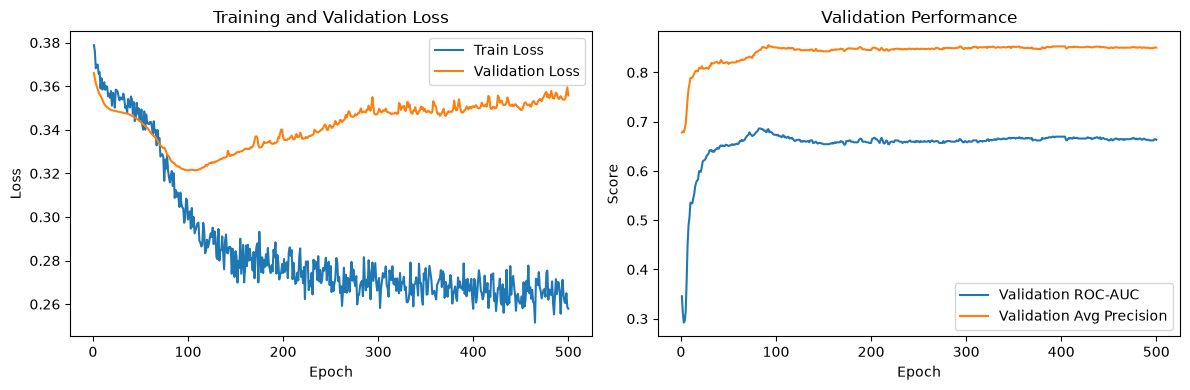

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_roc_auc"], label="Validation ROC-AUC")
axes[1].plot(history_df["epoch"], history_df["val_average_precision"], label="Validation Avg Precision")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation Performance")
axes[1].legend()

plt.tight_layout()
plt.show()

In [183]:
def smiles_to_morgan_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return np.zeros(n_bits)

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr


X = np.vstack([
    smiles_to_morgan_fp(smi)
    for smi in valid_df["Drug"]
])

y = valid_df["Y"].astype(int).values

X_train = X[train_idx]
X_val = X[val_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear"
)

logreg.fit(X_train, y_train)

logreg_test_probs = logreg.predict_proba(X_test)[:, 1]
logreg_test_preds = (logreg_test_probs >= 0.5).astype(int)

logreg_auc = roc_auc_score(y_test, logreg_test_probs)
logreg_acc = accuracy_score(y_test, logreg_test_preds)

print(f"Logistic Regression Test Accuracy: {logreg_acc:.3f}")
print(f"Logistic Regression Test ROC-AUC:  {logreg_auc:.3f}")

Logistic Regression Test Accuracy: 0.780
Logistic Regression Test ROC-AUC:  0.888


In [184]:
gnn_test_results = evaluate_gnn(model, test_loader, criterion)

gnn_test_y = gnn_test_results["y"]
gnn_test_probs = gnn_test_results["probs"]
gnn_test_preds = gnn_test_results["preds"]

print("GNN Test Metrics")
for k, v in gnn_test_results["metrics"].items():
    print(f"{k}: {v:.3f}")

print()
print("Logistic Regression Test Metrics")
print(f"accuracy: {logreg_acc:.3f}")
print(f"roc_auc:  {logreg_auc:.3f}")

GNN Test Metrics
loss: 0.238
accuracy: 0.780
roc_auc: 0.863
average_precision: 0.931

Logistic Regression Test Metrics
accuracy: 0.780
roc_auc:  0.888


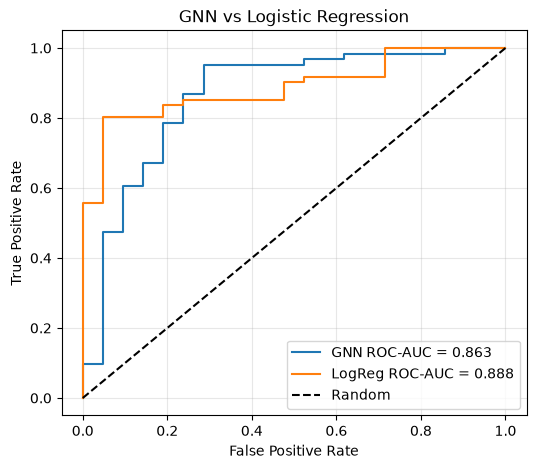

In [185]:
gnn_fpr, gnn_tpr, _ = roc_curve(gnn_test_y, gnn_test_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, logreg_test_probs)

gnn_auc = roc_auc_score(gnn_test_y, gnn_test_probs)
lr_auc = roc_auc_score(y_test, logreg_test_probs)

plt.figure(figsize=(6, 5))

plt.plot(gnn_fpr, gnn_tpr, label=f"GNN ROC-AUC = {gnn_auc:.3f}")
plt.plot(lr_fpr, lr_tpr, label=f"LogReg ROC-AUC = {lr_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GNN vs Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

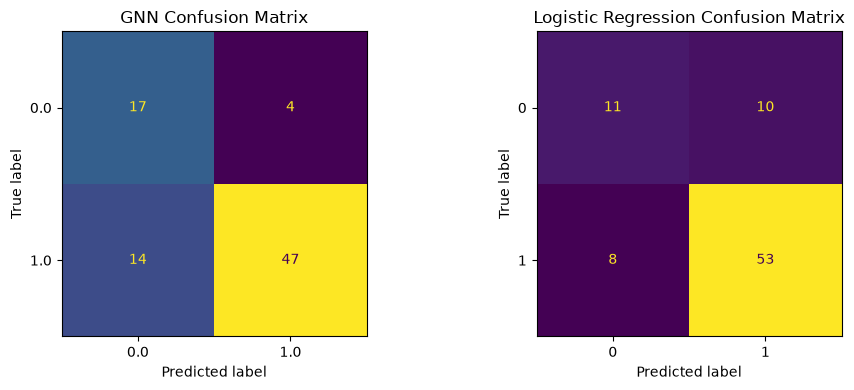

In [186]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    gnn_test_y,
    gnn_test_preds,
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("GNN Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logreg_test_preds,
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()

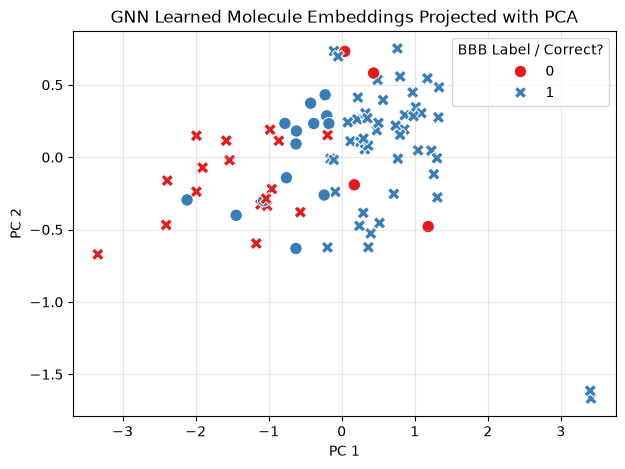

In [187]:
test_embeddings = gnn_test_results["embeddings"]
test_labels = gnn_test_results["y"].astype(int)
test_probs = gnn_test_results["probs"]
test_correct = gnn_test_results["preds"] == test_labels

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(test_embeddings)

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=emb_2d[:, 0],
    y=emb_2d[:, 1],
    hue=test_labels,
    style=test_correct,
    palette="Set1",
    s=80
)

plt.title("GNN Learned Molecule Embeddings Projected with PCA")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="BBB Label / Correct?")
plt.grid(alpha=0.3)
plt.show()

In [188]:
def atom_saliency(model, data):
    model.eval()

    data = data.to(device)

    x = data.x.clone().detach().requires_grad_(True)
    edge_index = data.edge_index
    batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

    logit = model(x, edge_index, batch)
    prob = torch.sigmoid(logit).item()

    model.zero_grad()
    logit.backward()

    saliency = x.grad.abs().sum(dim=1).detach().cpu().numpy()

    return prob, saliency


def visualize_atom_saliency(model, data, smiles, top_k=4):
    prob, saliency = atom_saliency(model, data)

    mol = Chem.MolFromSmiles(smiles)

    top_atoms = np.argsort(saliency)[-top_k:].tolist()

    print(f"Predicted BBB probability: {prob:.3f}")
    print(f"Top highlighted atom indices: {top_atoms}")

    img = Draw.MolToImage(
        mol,
        size=(350, 300),
        highlightAtoms=top_atoms
    )

    display(img)

    atom_labels = [
        f"{atom.GetSymbol()}{atom.GetIdx()}"
        for atom in mol.GetAtoms()
    ]

    plt.figure(figsize=(8, 3))
    plt.bar(atom_labels, saliency)
    plt.xticks(rotation=45)
    plt.ylabel("Gradient Saliency")
    plt.title("Atom-Level Saliency")
    plt.tight_layout()
    plt.show()

True label: 1
SMILES: CCCCCCCCCC1(C)OCC(COC(N)=O)O1
Predicted BBB probability: 0.548
Top highlighted atom indices: [12, 11, 13, 9]


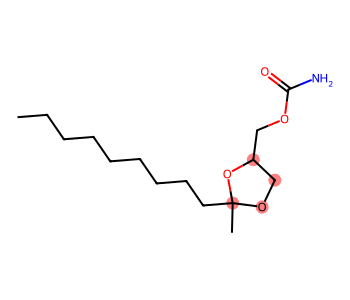

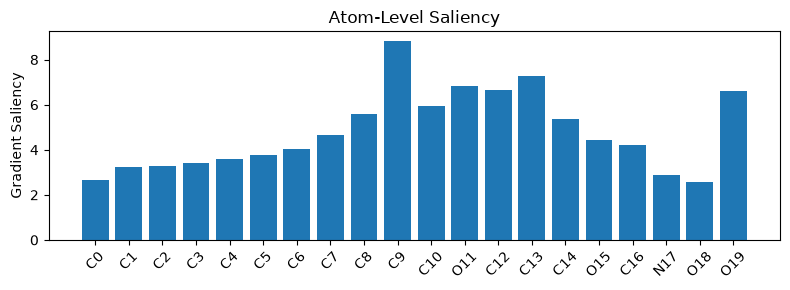

In [189]:
# Pick a confident correct example if possible
correct_indices = np.where(gnn_test_preds == gnn_test_y)[0]

if len(correct_indices) > 0:
    local_i = correct_indices[0]
else:
    local_i = 0

global_i = test_idx[local_i]

example_data = data_list[global_i]
example_smiles = valid_df.iloc[global_i]["Drug"]
example_label = valid_df.iloc[global_i]["Y"]

print(f"True label: {example_label}")
print(f"SMILES: {example_smiles}")

visualize_atom_saliency(model, example_data, example_smiles)

#### Molecule Descriptive Exploration

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, Lipinski, Crippen, rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display

import networkx as nx

Row index: 0
SMILES: CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](CC[C@@H]3C[C@@H](O)CC(=O)O3)[C@H]21
BBB label Y: 1


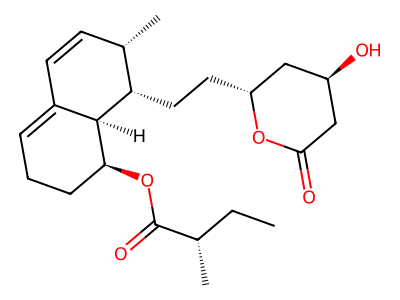

In [52]:
# Pick one molecule to inspect
# Try changing this number!
mol_index = 0

smiles = df.iloc[mol_index]["Drug"]
label = int(df.iloc[mol_index]["Y"])

mol = Chem.MolFromSmiles(smiles)

print(f"Row index: {mol_index}")
print(f"SMILES: {smiles}")
print(f"BBB label Y: {label}")

display(Draw.MolToImage(mol, size=(400, 300)))

In [53]:
def calculate_molecule_features(smiles):
    """
    Calculate deterministic, human-readable molecular descriptors.
    These are useful for explaining what chemists and simpler ML models might use.
    """
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None
    
    features = {
        "Molecular Weight": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "H-Bond Donors": Lipinski.NumHDonors(mol),
        "H-Bond Acceptors": Lipinski.NumHAcceptors(mol),
        "Rotatable Bonds": Lipinski.NumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "Aromatic Rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "Heavy Atoms": mol.GetNumHeavyAtoms(),
        "Heteroatoms": rdMolDescriptors.CalcNumHeteroatoms(mol),
        "Formal Charge": Chem.GetFormalCharge(mol),
        "Fraction Csp3": rdMolDescriptors.CalcFractionCSP3(mol),
    }
    
    return features


features = calculate_molecule_features(smiles)

feature_df = pd.DataFrame(
    features.items(),
    columns=["Feature", "Value"]
)

feature_df

,Feature,Value
0,Molecular Weight,390.52000
1,LogP,3.94950
2,TPSA,72.83000
3,H-Bond Donors,1.00000
4,H-Bond Acceptors,5.00000
5,Rotatable Bonds,6.00000
6,Rings,3.00000
7,Aromatic Rings,0.00000
8,Heavy Atoms,28.00000
9,Heteroatoms,5.00000


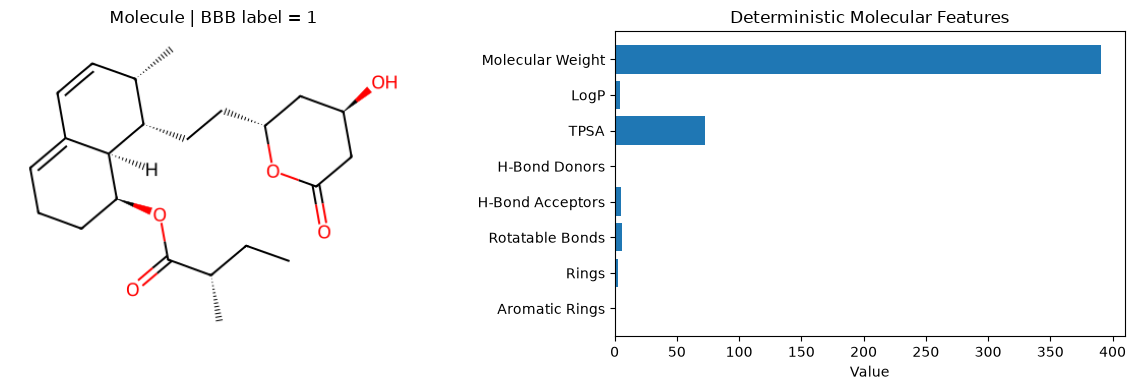

In [54]:
def molecule_card(smiles, label=None):
    mol = Chem.MolFromSmiles(smiles)
    features = calculate_molecule_features(smiles)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Left: molecule image
    img = Draw.MolToImage(mol, size=(400, 300))
    axes[0].imshow(img)
    axes[0].axis("off")
    
    title = "Molecule"
    if label is not None:
        title += f" | BBB label = {label}"
    axes[0].set_title(title)
    
    # Right: selected key descriptors
    key_features = [
        "Molecular Weight",
        "LogP",
        "TPSA",
        "H-Bond Donors",
        "H-Bond Acceptors",
        "Rotatable Bonds",
        "Rings",
        "Aromatic Rings"
    ]
    
    values = [features[k] for k in key_features]
    
    axes[1].barh(key_features, values)
    axes[1].invert_yaxis()
    axes[1].set_title("Deterministic Molecular Features")
    axes[1].set_xlabel("Value")
    
    plt.tight_layout()
    plt.show()


molecule_card(smiles, label)

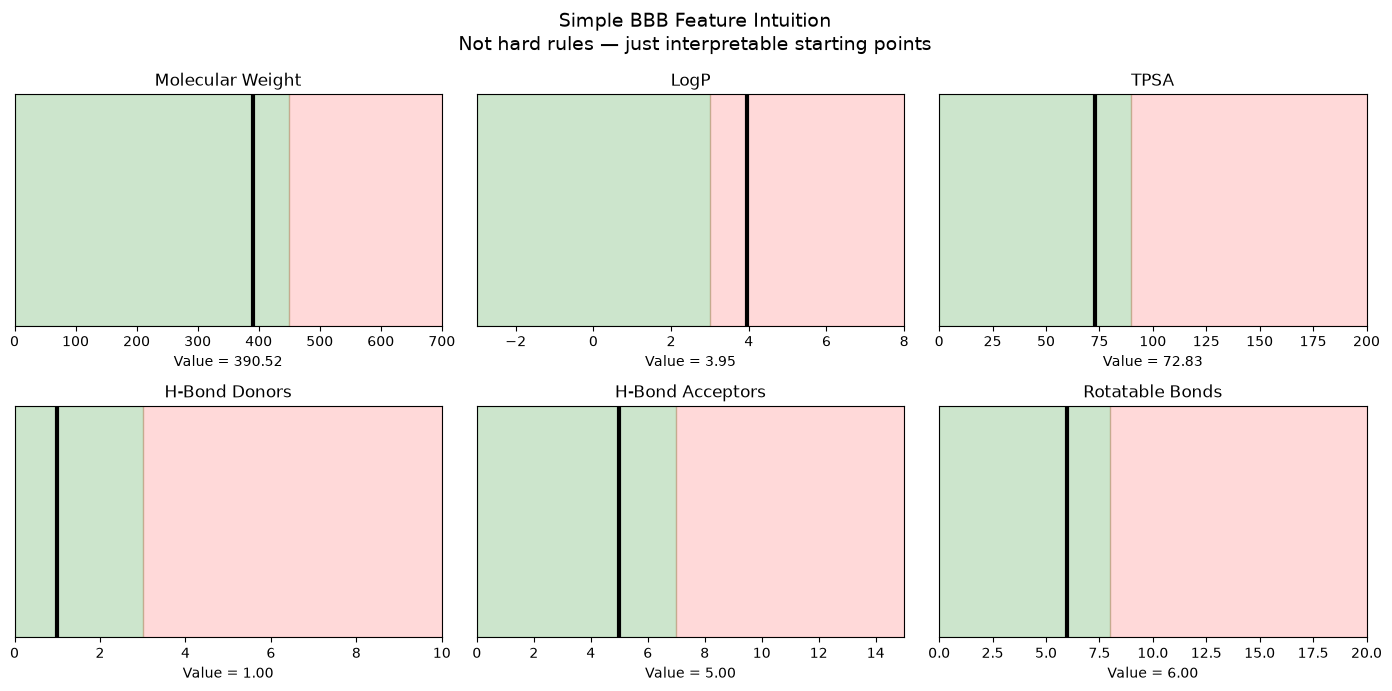

,Feature,Value,Common BBB-friendly intuition
0,Molecular Weight,390.5200,Often lower is easier
1,LogP,3.9495,Moderate lipophilicity often helps
2,TPSA,72.8300,Lower polar surface area often helps
3,H-Bond Donors,1.0000,Fewer donors often helps
4,H-Bond Acceptors,5.0000,Fewer acceptors often helps
5,Rotatable Bonds,6.0000,Fewer flexible bonds often helps


In [55]:
def plot_bbb_feature_guide(smiles):
    features = calculate_molecule_features(smiles)
    
    guide = pd.DataFrame({
        "Feature": [
            "Molecular Weight",
            "LogP",
            "TPSA",
            "H-Bond Donors",
            "H-Bond Acceptors",
            "Rotatable Bonds"
        ],
        "Value": [
            features["Molecular Weight"],
            features["LogP"],
            features["TPSA"],
            features["H-Bond Donors"],
            features["H-Bond Acceptors"],
            features["Rotatable Bonds"]
        ],
        "Common BBB-friendly intuition": [
            "Often lower is easier",
            "Moderate lipophilicity often helps",
            "Lower polar surface area often helps",
            "Fewer donors often helps",
            "Fewer acceptors often helps",
            "Fewer flexible bonds often helps"
        ]
    })
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.flatten()
    
    ranges = {
        "Molecular Weight": (0, 700, 450),
        "LogP": (-3, 8, 3),
        "TPSA": (0, 200, 90),
        "H-Bond Donors": (0, 10, 3),
        "H-Bond Acceptors": (0, 15, 7),
        "Rotatable Bonds": (0, 20, 8)
    }
    
    for ax, row in zip(axes, guide.itertuples()):
        feature = row.Feature
        value = row.Value
        xmin, xmax, threshold = ranges[feature]
        
        ax.axvspan(xmin, threshold, alpha=0.2, color="green", label="Often favorable")
        ax.axvspan(threshold, xmax, alpha=0.15, color="red", label="Often less favorable")
        ax.axvline(value, color="black", linewidth=3)
        
        ax.set_xlim(xmin, xmax)
        ax.set_yticks([])
        ax.set_title(feature)
        ax.set_xlabel(f"Value = {value:.2f}")
    
    plt.suptitle("Simple BBB Feature Intuition\nNot hard rules — just interpretable starting points", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return guide


bbb_guide_df = plot_bbb_feature_guide(smiles)
bbb_guide_df

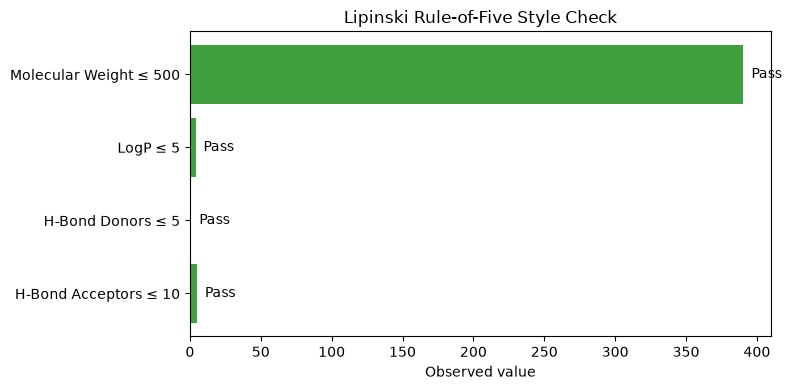

,Rule,Value,Pass
0,Molecular Weight ≤ 500,390.5200,True
1,LogP ≤ 5,3.9495,True
2,H-Bond Donors ≤ 5,1.0000,True
3,H-Bond Acceptors ≤ 10,5.0000,True


In [56]:
def lipinski_visual(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    
    rules = pd.DataFrame({
        "Rule": [
            "Molecular Weight ≤ 500",
            "LogP ≤ 5",
            "H-Bond Donors ≤ 5",
            "H-Bond Acceptors ≤ 10"
        ],
        "Value": [mw, logp, hbd, hba],
        "Pass": [
            mw <= 500,
            logp <= 5,
            hbd <= 5,
            hba <= 10
        ]
    })
    
    colors = ["green" if x else "red" for x in rules["Pass"]]
    
    plt.figure(figsize=(8, 4))
    plt.barh(rules["Rule"], rules["Value"], color=colors, alpha=0.75)
    plt.xlabel("Observed value")
    plt.title("Lipinski Rule-of-Five Style Check")
    plt.gca().invert_yaxis()
    
    for i, row in rules.iterrows():
        status = "Pass" if row["Pass"] else "Fail"
        plt.text(row["Value"], i, f"  {status}", va="center")
    
    plt.tight_layout()
    plt.show()
    
    return rules


lipinski_visual(smiles)

In [57]:
def atom_feature_table(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    rows = []
    for atom in mol.GetAtoms():
        rows.append({
            "Atom Index": atom.GetIdx(),
            "Element": atom.GetSymbol(),
            "Atomic Number": atom.GetAtomicNum(),
            "Degree": atom.GetDegree(),
            "Total Hydrogens": atom.GetTotalNumHs(),
            "Formal Charge": atom.GetFormalCharge(),
            "Hybridization": str(atom.GetHybridization()),
            "Is Aromatic": atom.GetIsAromatic(),
            "Is In Ring": atom.IsInRing(),
            "Mass": atom.GetMass()
        })
    
    return pd.DataFrame(rows)


atom_df = atom_feature_table(smiles)
atom_df

,Atom Index,Element,Atomic Number,Degree,Total Hydrogens,Formal Charge,Hybridization,Is Aromatic,Is In Ring,Mass
0,0,C,6,1,3,0,SP3,False,False,12.011
1,1,C,6,2,2,0,SP3,False,False,12.011
2,2,C,6,3,1,0,SP3,False,False,12.011
3,3,C,6,1,3,0,SP3,False,False,12.011
4,4,C,6,3,0,0,SP2,False,False,12.011
5,5,O,8,1,0,0,SP2,False,False,15.999
6,6,O,8,2,0,0,SP2,False,False,15.999
7,7,C,6,3,1,0,SP3,False,True,12.011
8,8,C,6,2,2,0,SP3,False,True,12.011
9,9,C,6,2,2,0,SP3,False,True,12.011


Highlight type: heteroatoms
Highlighted atom indices: [5, 6, 22, 25, 26]


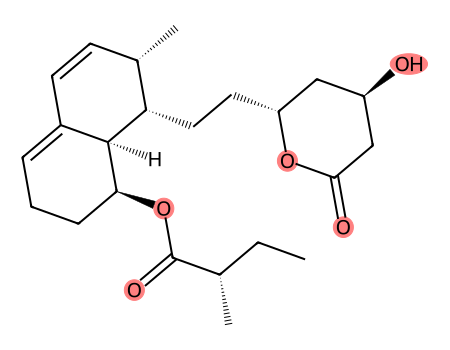

Highlight type: aromatic
Highlighted atom indices: []


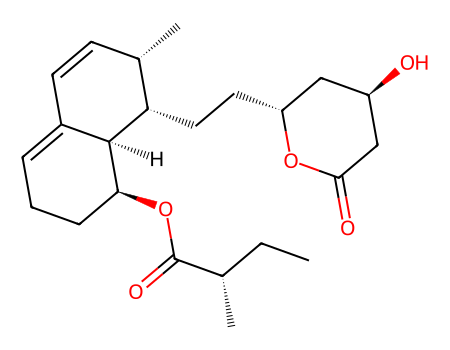

Highlight type: ring
Highlighted atom indices: [7, 8, 9, 10, 11, 12, 13, 14, 16, 19, 20, 21, 23, 24, 26, 27]


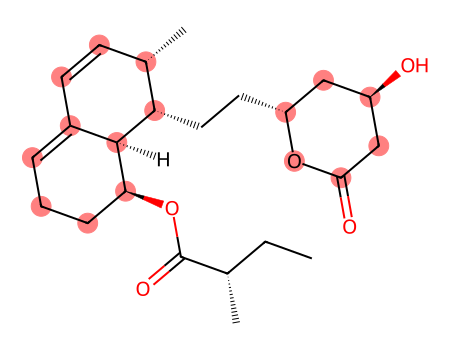

Highlight type: charged
Highlighted atom indices: []


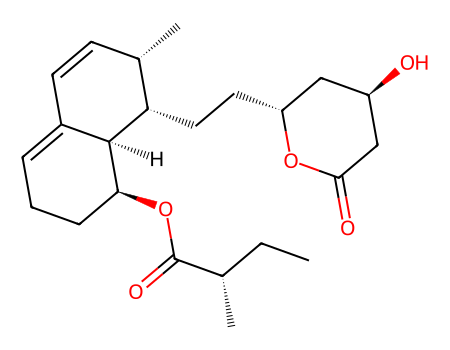

In [58]:
def draw_highlighted_atoms(smiles, highlight_type="heteroatoms"):
    mol = Chem.MolFromSmiles(smiles)
    
    highlight_atoms = []
    
    for atom in mol.GetAtoms():
        if highlight_type == "heteroatoms":
            if atom.GetAtomicNum() not in [1, 6]:
                highlight_atoms.append(atom.GetIdx())
        
        elif highlight_type == "aromatic":
            if atom.GetIsAromatic():
                highlight_atoms.append(atom.GetIdx())
        
        elif highlight_type == "ring":
            if atom.IsInRing():
                highlight_atoms.append(atom.GetIdx())
        
        elif highlight_type == "charged":
            if atom.GetFormalCharge() != 0:
                highlight_atoms.append(atom.GetIdx())
    
    print(f"Highlight type: {highlight_type}")
    print(f"Highlighted atom indices: {highlight_atoms}")
    
    img = Draw.MolToImage(
        mol,
        size=(450, 350),
        highlightAtoms=highlight_atoms
    )
    
    display(img)


draw_highlighted_atoms(smiles, "heteroatoms")
draw_highlighted_atoms(smiles, "aromatic")
draw_highlighted_atoms(smiles, "ring")
draw_highlighted_atoms(smiles, "charged")

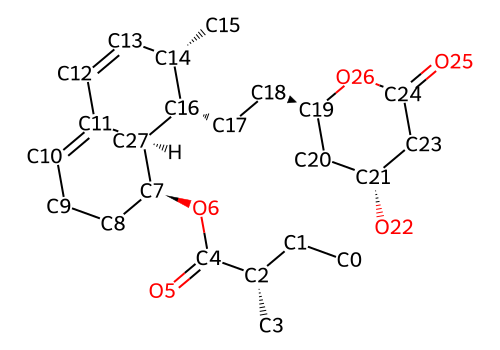

In [59]:
def draw_molecule_with_atom_indices(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    for atom in mol.GetAtoms():
        atom.SetProp("atomLabel", f"{atom.GetSymbol()}{atom.GetIdx()}")
    
    drawer = rdMolDraw2D.MolDraw2DSVG(500, 350)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    
    display(SVG(drawer.GetDrawingText()))


draw_molecule_with_atom_indices(smiles)

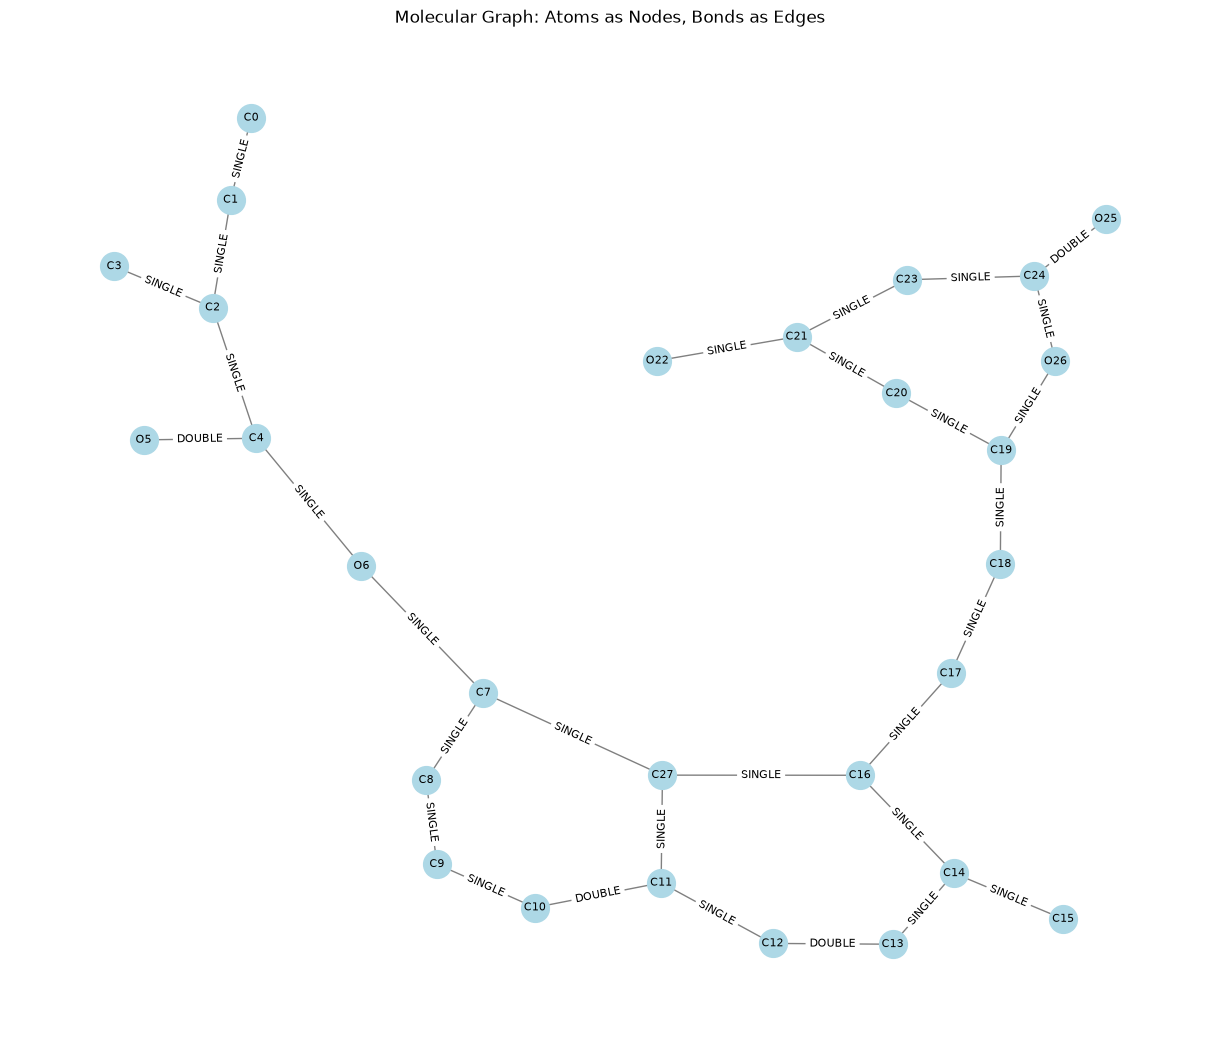

In [71]:
def plot_molecular_graph_with_atom_labels(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    G = nx.Graph()
    
    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        label = f"{atom.GetSymbol()}{idx}"
        G.add_node(idx, label=label)
    
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        G.add_edge(i, j, bond_type=str(bond.GetBondType()))
    
    pos = nx.spring_layout(G, seed=42)
    
    labels = nx.get_node_attributes(G, "label")
    edge_labels = nx.get_edge_attributes(G, "bond_type")
    
    plt.figure(figsize=(12,10))
    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=400,
        node_color="lightblue",
        edge_color="gray",
        font_size=8
    )
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    
    plt.title("Molecular Graph: Atoms as Nodes, Bonds as Edges")
    plt.axis("off")
    plt.show()


plot_molecular_graph_with_atom_labels(smiles)

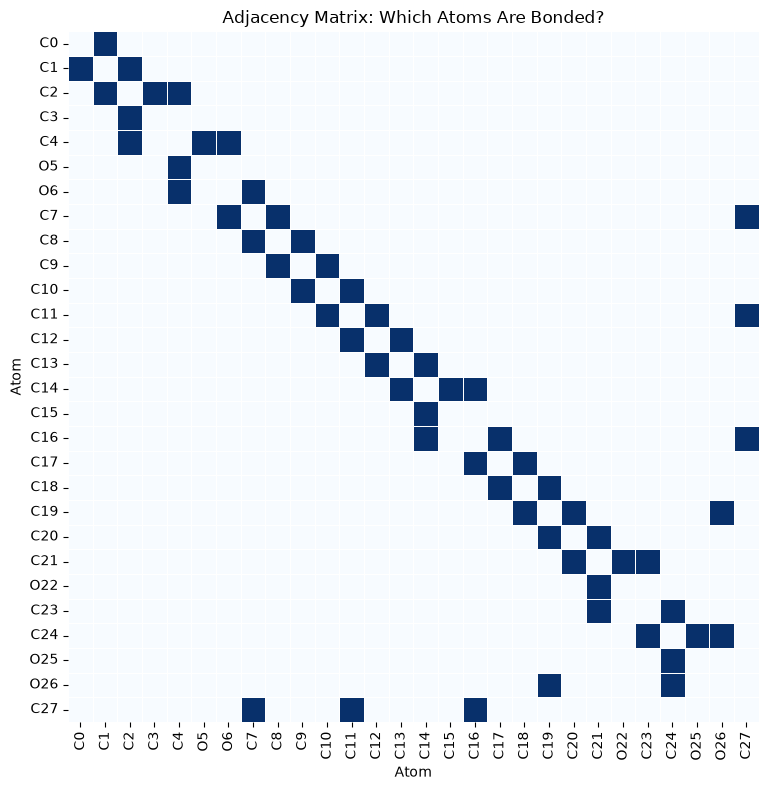

,C0,C1,C2,C3,C4,O5,O6,C7,C8,C9,...,C18,C19,C20,C21,O22,C23,C24,O25,O26,C27
C0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C2,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C4,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
C8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
def plot_adjacency_matrix(smiles):
    mol = Chem.MolFromSmiles(smiles)
    n_atoms = mol.GetNumAtoms()
    
    adjacency = np.zeros((n_atoms, n_atoms))
    
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        adjacency[i, j] = 1
        adjacency[j, i] = 1
    
    atom_labels = [
        f"{atom.GetSymbol()}{atom.GetIdx()}"
        for atom in mol.GetAtoms()
    ]
    
    plt.figure(figsize=(8,8))
    sns.heatmap(
        adjacency,
        cmap="Blues",
        square=True,
        xticklabels=atom_labels,
        yticklabels=atom_labels,
        cbar=False,
        linewidths=0.5
    )
    plt.title("Adjacency Matrix: Which Atoms Are Bonded?")
    plt.xlabel("Atom")
    plt.ylabel("Atom")
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(adjacency, index=atom_labels, columns=atom_labels)


adjacency_df = plot_adjacency_matrix(smiles)
adjacency_df

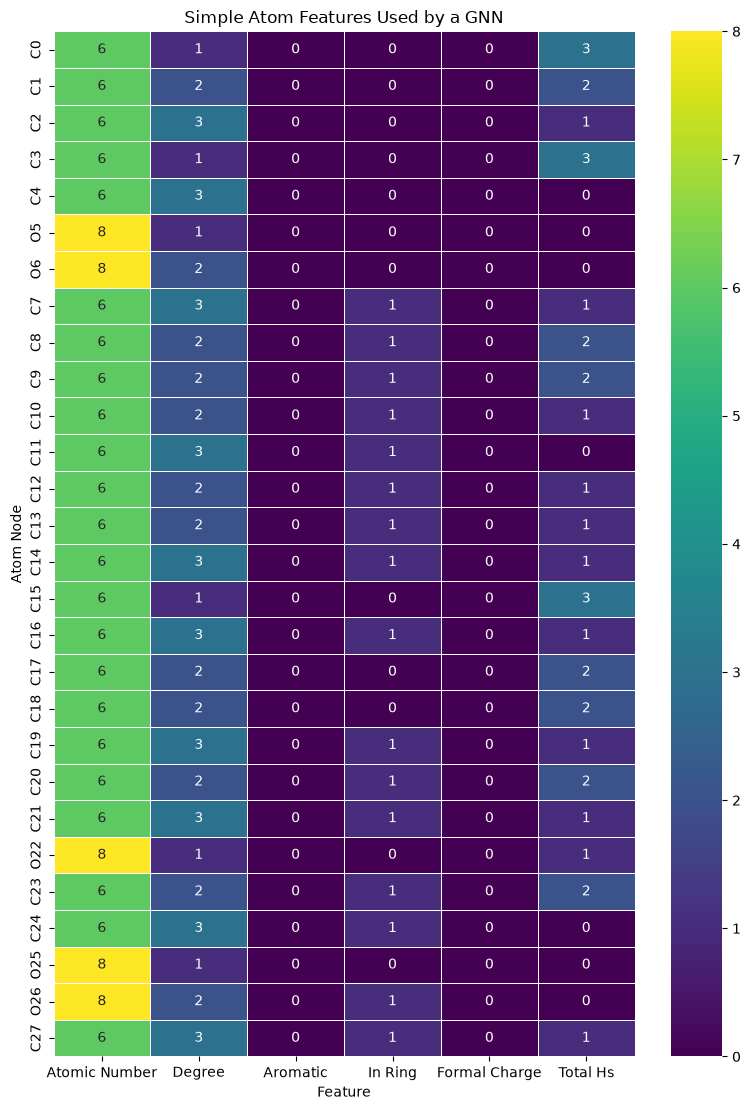

,Atomic Number,Degree,Aromatic,In Ring,Formal Charge,Total Hs
Atom,,,,,,
C0,6,1,0,0,0,3
C1,6,2,0,0,0,2
C2,6,3,0,0,0,1
C3,6,1,0,0,0,3
C4,6,3,0,0,0,0
O5,8,1,0,0,0,0
O6,8,2,0,0,0,0
C7,6,3,0,1,0,1
C8,6,2,0,1,0,2


In [62]:
def simple_node_features(smiles):
    """
    Matches your original intro-friendly GNN node features:
    atomic number and atom degree.
    """
    mol = Chem.MolFromSmiles(smiles)
    
    rows = []
    for atom in mol.GetAtoms():
        rows.append({
            "Atom": f"{atom.GetSymbol()}{atom.GetIdx()}",
            "Atomic Number": atom.GetAtomicNum(),
            "Degree": atom.GetDegree(),
            "Aromatic": int(atom.GetIsAromatic()),
            "In Ring": int(atom.IsInRing()),
            "Formal Charge": atom.GetFormalCharge(),
            "Total Hs": atom.GetTotalNumHs()
        })
    
    return pd.DataFrame(rows).set_index("Atom")


node_feature_df = simple_node_features(smiles)

plt.figure(figsize=(8, max(3, 0.4 * len(node_feature_df))))
sns.heatmap(
    node_feature_df,
    annot=True,
    cmap="viridis",
    linewidths=0.5
)
plt.title("Simple Atom Features Used by a GNN")
plt.xlabel("Feature")
plt.ylabel("Atom Node")
plt.tight_layout()
plt.show()

node_feature_df

In [63]:
def add_descriptor_columns(df, smiles_col="Drug"):
    descriptor_rows = []
    
    for smi in df[smiles_col]:
        feats = calculate_molecule_features(smi)
        descriptor_rows.append(feats)
    
    descriptor_df = pd.DataFrame(descriptor_rows)
    return pd.concat([df.reset_index(drop=True), descriptor_df], axis=1)


# This can take a few seconds depending on dataset size
df_desc = add_descriptor_columns(df)

df_desc.head()

,Drug_ID,Drug,Y,Molecular Weight,LogP,TPSA,H-Bond Donors,H-Bond Acceptors,Rotatable Bonds,Rings,Aromatic Rings,Heavy Atoms,Heteroatoms,Formal Charge,Fraction Csp3
0,mevastatin,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1,390.520,3.94950,72.83,1,5,6,3,0,28,5,0,0.739130
1,anseculin,COc1cc2oc(=O)c(C)c(C)c2cc1OCCCN1CCN(c2ccccc2OC...,1,452.551,4.01814,64.38,0,7,8,4,3,33,7,0,0.423077
2,moxalactam,CO[C@@]1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C...,0,520.480,-1.12770,206.30,4,11,9,4,2,36,16,0,0.350000
3,taclamine,c1ccc2c(c1)CCc1cccc3c1C2CN1CCCCC31,1,289.422,4.45770,3.24,0,1,0,5,2,22,1,0,0.428571
4,indriline,CN(C)CCC1(c2ccccc2)C=Cc2ccccc21,1,263.384,3.95120,3.24,0,1,4,3,2,20,1,0,0.263158


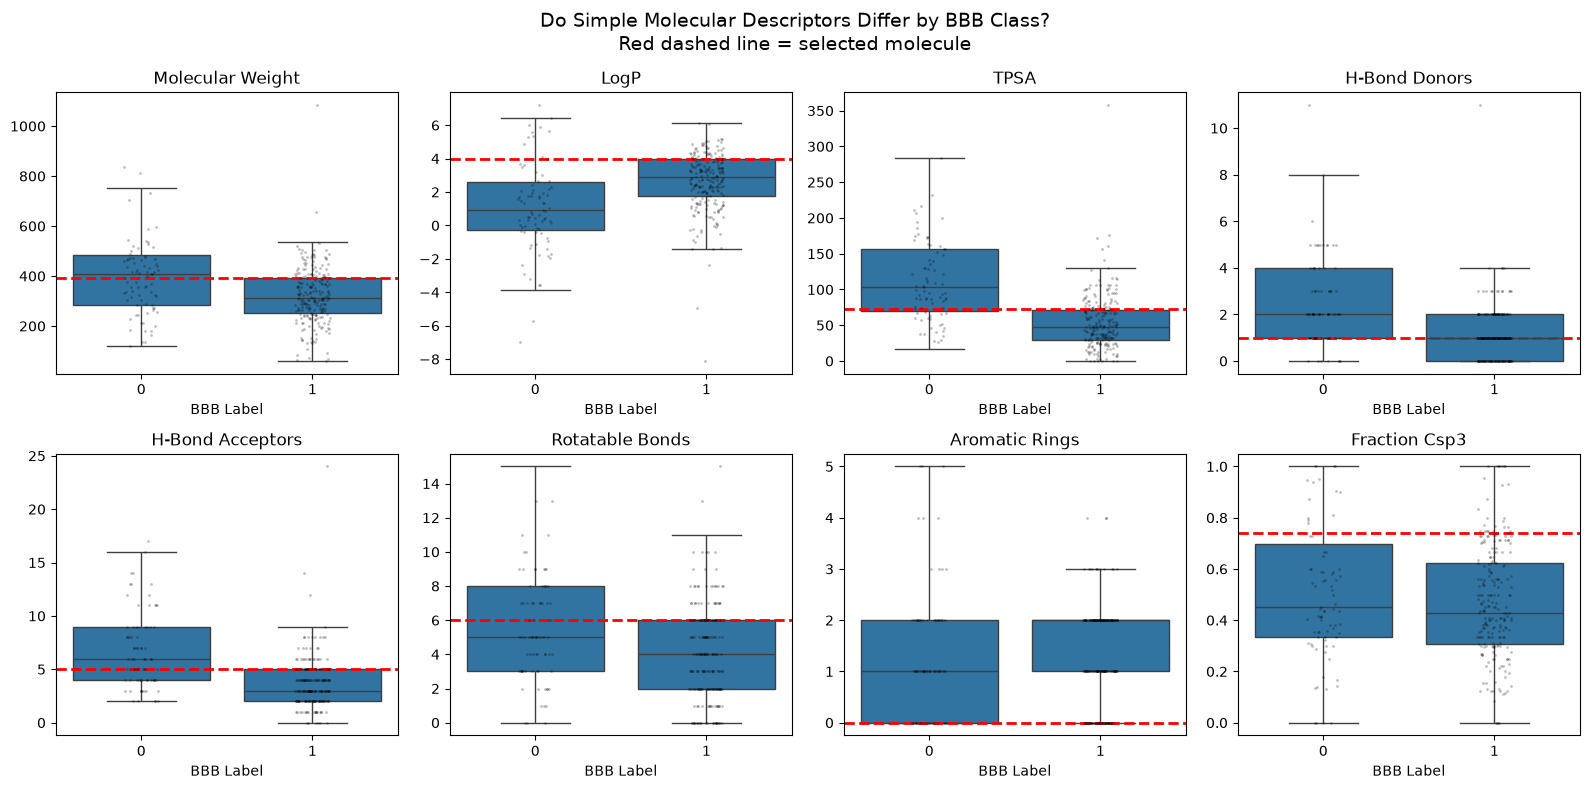

In [64]:
features_to_plot = [
    "Molecular Weight",
    "LogP",
    "TPSA",
    "H-Bond Donors",
    "H-Bond Acceptors",
    "Rotatable Bonds",
    "Aromatic Rings",
    "Fraction Csp3"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features_to_plot):
    sns.boxplot(
        data=df_desc,
        x="Y",
        y=feature,
        ax=ax,
        showfliers=False
    )
    sns.stripplot(
        data=df_desc.sample(min(len(df_desc), 300), random_state=42),
        x="Y",
        y=feature,
        ax=ax,
        color="black",
        alpha=0.25,
        size=2
    )
    
    selected_value = df_desc.iloc[mol_index][feature]
    ax.axhline(selected_value, color="red", linestyle="--", linewidth=2)
    
    ax.set_title(feature)
    ax.set_xlabel("BBB Label")
    ax.set_ylabel("")
    
plt.suptitle(
    "Do Simple Molecular Descriptors Differ by BBB Class?\n"
    "Red dashed line = selected molecule",
    fontsize=14
)
plt.tight_layout()
plt.show()

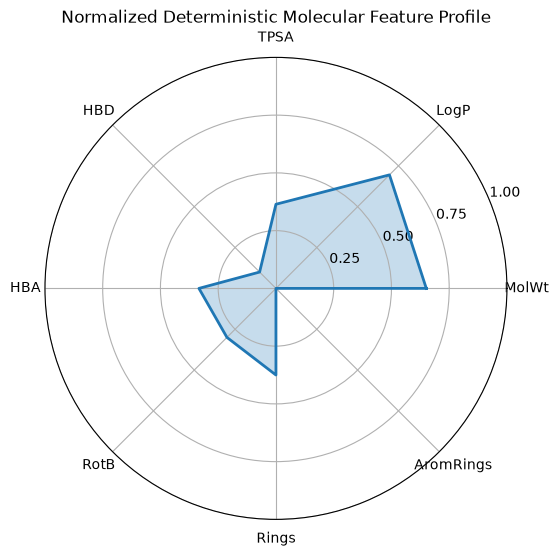

In [65]:
def radar_plot_molecule(smiles):
    features = calculate_molecule_features(smiles)
    
    radar_features = {
        "MolWt": features["Molecular Weight"] / 600,
        "LogP": (features["LogP"] + 3) / 10,
        "TPSA": features["TPSA"] / 200,
        "HBD": features["H-Bond Donors"] / 10,
        "HBA": features["H-Bond Acceptors"] / 15,
        "RotB": features["Rotatable Bonds"] / 20,
        "Rings": features["Rings"] / 8,
        "AromRings": features["Aromatic Rings"] / 6
    }
    
    labels = list(radar_features.keys())
    values = np.array(list(radar_features.values()))
    values = np.clip(values, 0, 1)
    
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
    
    values = np.concatenate([values, [values[0]]])
    angles = np.concatenate([angles, [angles[0]]])
    
    fig = plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)
    
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"])
    ax.set_title("Normalized Deterministic Molecular Feature Profile")
    
    plt.show()


radar_plot_molecule(smiles)

Number of active Morgan fingerprint bits: 59
Showing up to 8 active bits


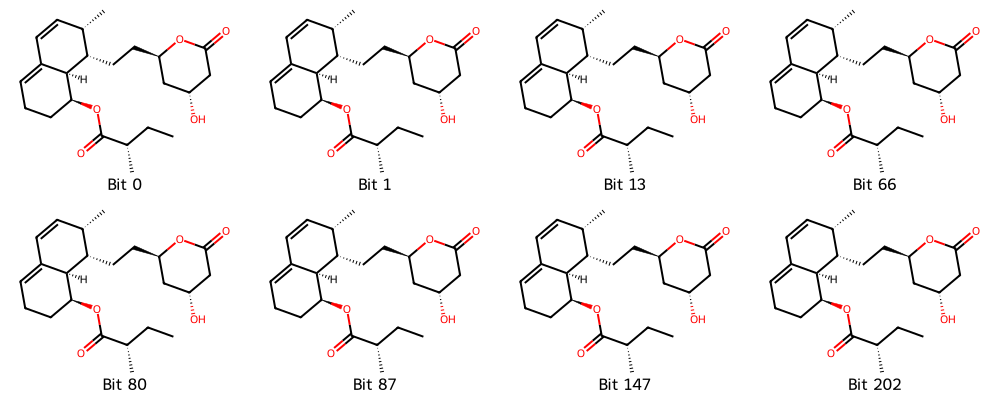

Note: The grid above labels active fingerprint bits, but the full substructure drawing may depend on RDKit rendering behavior.


In [66]:
def show_morgan_fingerprint_bits(smiles, radius=2, n_bits=2048, max_bits=8):
    mol = Chem.MolFromSmiles(smiles)
    
    bit_info = {}
    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(
        mol,
        radius=radius,
        nBits=n_bits,
        bitInfo=bit_info
    )
    
    on_bits = list(fp.GetOnBits())
    
    print(f"Number of active Morgan fingerprint bits: {len(on_bits)}")
    print(f"Showing up to {max_bits} active bits")
    
    selected_bits = on_bits[:max_bits]
    
    bit_images = []
    legends = []
    
    for bit in selected_bits:
        try:
            img = Draw.DrawMorganBit(mol, bit, bit_info)
            bit_images.append(img)
            legends.append(f"Bit {bit}")
        except Exception as e:
            print(f"Could not draw bit {bit}: {e}")
    
    if len(bit_images) > 0:
        display(
            Draw.MolsToGridImage(
                [mol] * len(bit_images),
                molsPerRow=4,
                subImgSize=(250, 200),
                legends=legends
            )
        )
        
        print(
            "Note: The grid above labels active fingerprint bits, but the full substructure "
            "drawing may depend on RDKit rendering behavior."
        )
    
    return selected_bits, bit_info


selected_bits, bit_info = show_morgan_fingerprint_bits(smiles)

Morgan fingerprint bit: 0


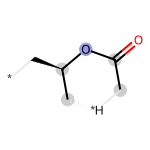

Morgan fingerprint bit: 1


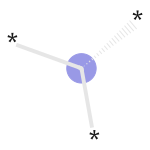

Morgan fingerprint bit: 13


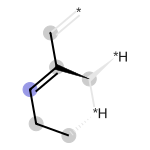

Morgan fingerprint bit: 66


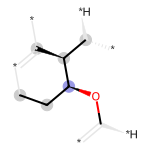

Morgan fingerprint bit: 80


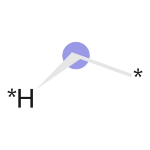

Morgan fingerprint bit: 87


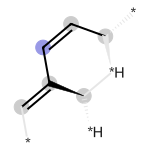

Morgan fingerprint bit: 147


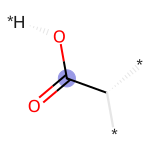

Morgan fingerprint bit: 202


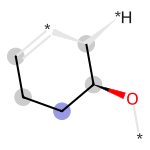

In [67]:
def display_morgan_bit_drawings(smiles, radius=2, n_bits=2048, max_bits=8):
    mol = Chem.MolFromSmiles(smiles)
    
    bit_info = {}
    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(
        mol,
        radius=radius,
        nBits=n_bits,
        bitInfo=bit_info
    )
    
    on_bits = list(fp.GetOnBits())[:max_bits]
    
    for bit in on_bits:
        print(f"Morgan fingerprint bit: {bit}")
        display(Draw.DrawMorganBit(mol, bit, bit_info))


display_morgan_bit_drawings(smiles)

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

descriptor_features = [
    "Molecular Weight",
    "LogP",
    "TPSA",
    "H-Bond Donors",
    "H-Bond Acceptors",
    "Rotatable Bonds",
    "Rings",
    "Aromatic Rings",
    "Heavy Atoms",
    "Heteroatoms",
    "Formal Charge",
    "Fraction Csp3"
]

X_desc = df_desc[descriptor_features].values
y = df_desc["Y"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X_desc,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

desc_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

desc_model.fit(X_train, y_train)

desc_probs = desc_model.predict_proba(X_test)[:, 1]
desc_preds = (desc_probs >= 0.5).astype(int)

print(f"Descriptor Logistic Regression Accuracy: {accuracy_score(y_test, desc_preds):.3f}")
print(f"Descriptor Logistic Regression ROC-AUC:  {roc_auc_score(y_test, desc_probs):.3f}")

Descriptor Logistic Regression Accuracy: 0.866
Descriptor Logistic Regression ROC-AUC:  0.849


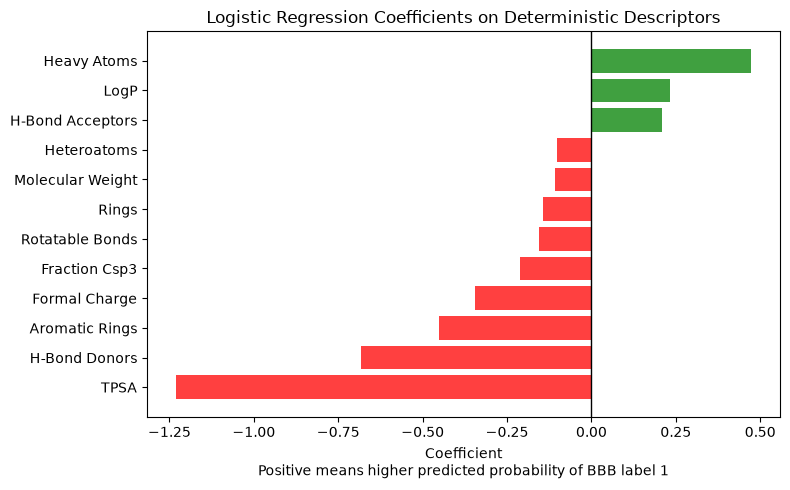

,Feature,Coefficient
2,TPSA,-1.231305
3,H-Bond Donors,-0.682342
7,Aromatic Rings,-0.452167
10,Formal Charge,-0.344891
11,Fraction Csp3,-0.210847
5,Rotatable Bonds,-0.155384
6,Rings,-0.142116
0,Molecular Weight,-0.109336
9,Heteroatoms,-0.101203
4,H-Bond Acceptors,0.209865


In [69]:
logreg = desc_model.named_steps["logreg"]

coef_df = pd.DataFrame({
    "Feature": descriptor_features,
    "Coefficient": logreg.coef_[0]
}).sort_values("Coefficient")

plt.figure(figsize=(8, 5))
colors = ["red" if c < 0 else "green" for c in coef_df["Coefficient"]]

plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, alpha=0.75)
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients on Deterministic Descriptors")
plt.xlabel("Coefficient\nPositive means higher predicted probability of BBB label 1")
plt.tight_layout()
plt.show()

coef_df

Row index: 0
SMILES: CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](CC[C@@H]3C[C@@H](O)CC(=O)O3)[C@H]21
BBB label: 1


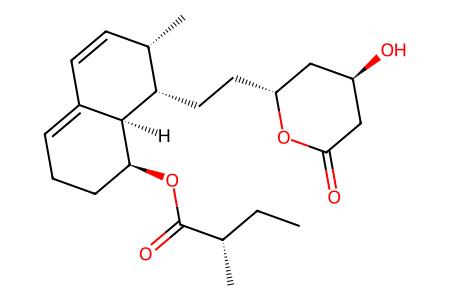

,Feature,Value
0,Molecular Weight,390.52000
1,LogP,3.94950
2,TPSA,72.83000
3,H-Bond Donors,1.00000
4,H-Bond Acceptors,5.00000
5,Rotatable Bonds,6.00000
6,Rings,3.00000
7,Aromatic Rings,0.00000
8,Heavy Atoms,28.00000
9,Heteroatoms,5.00000


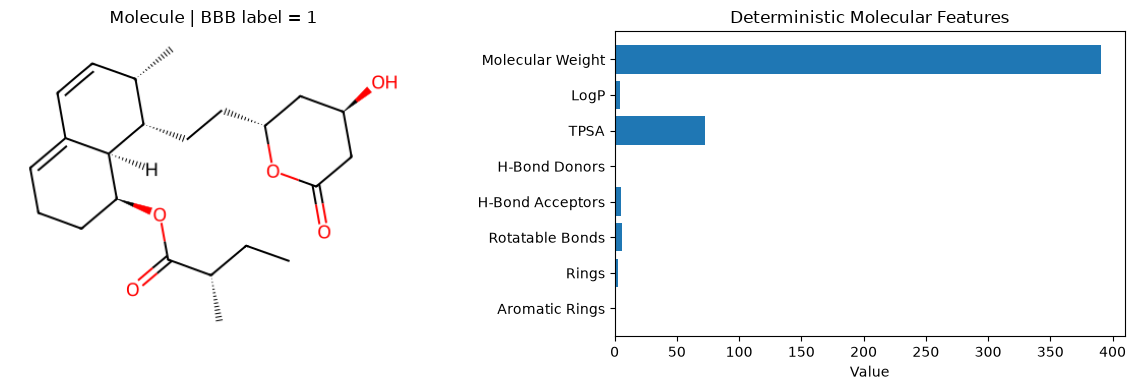

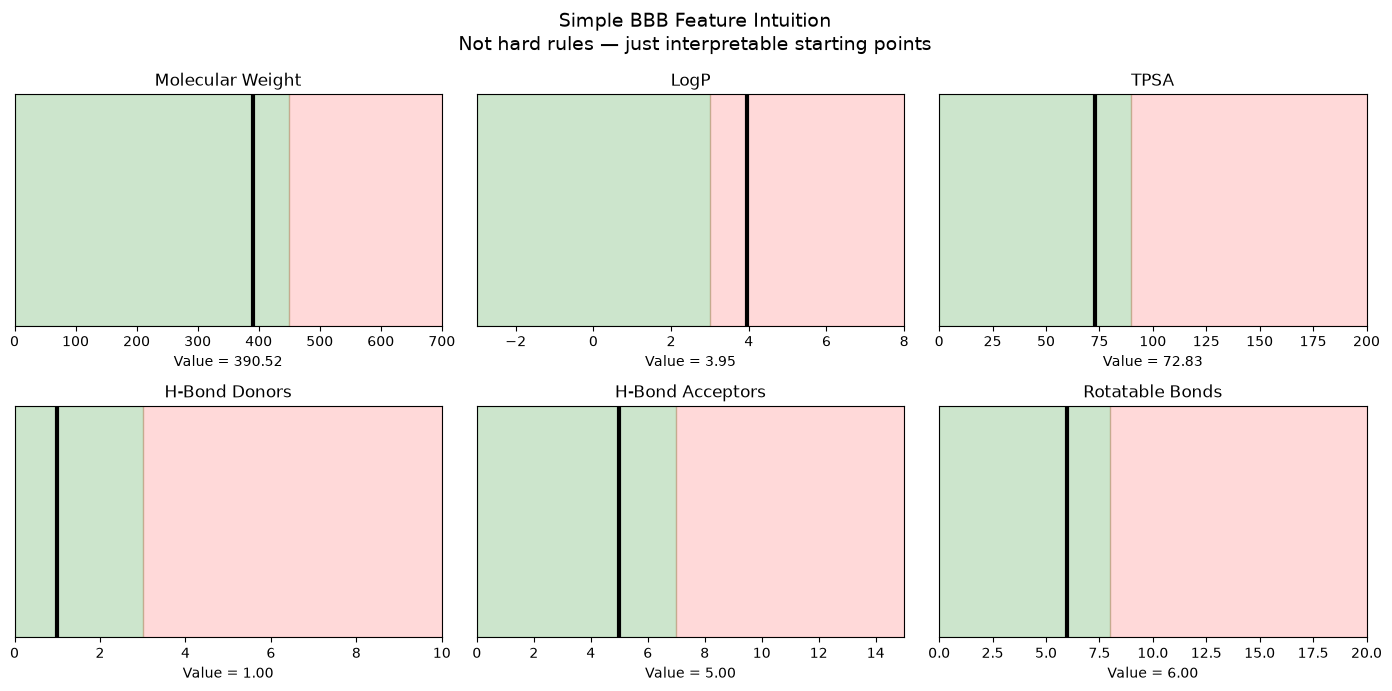

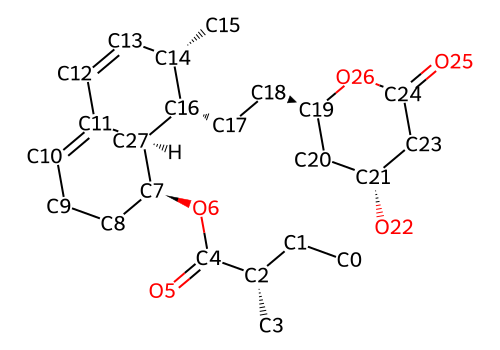

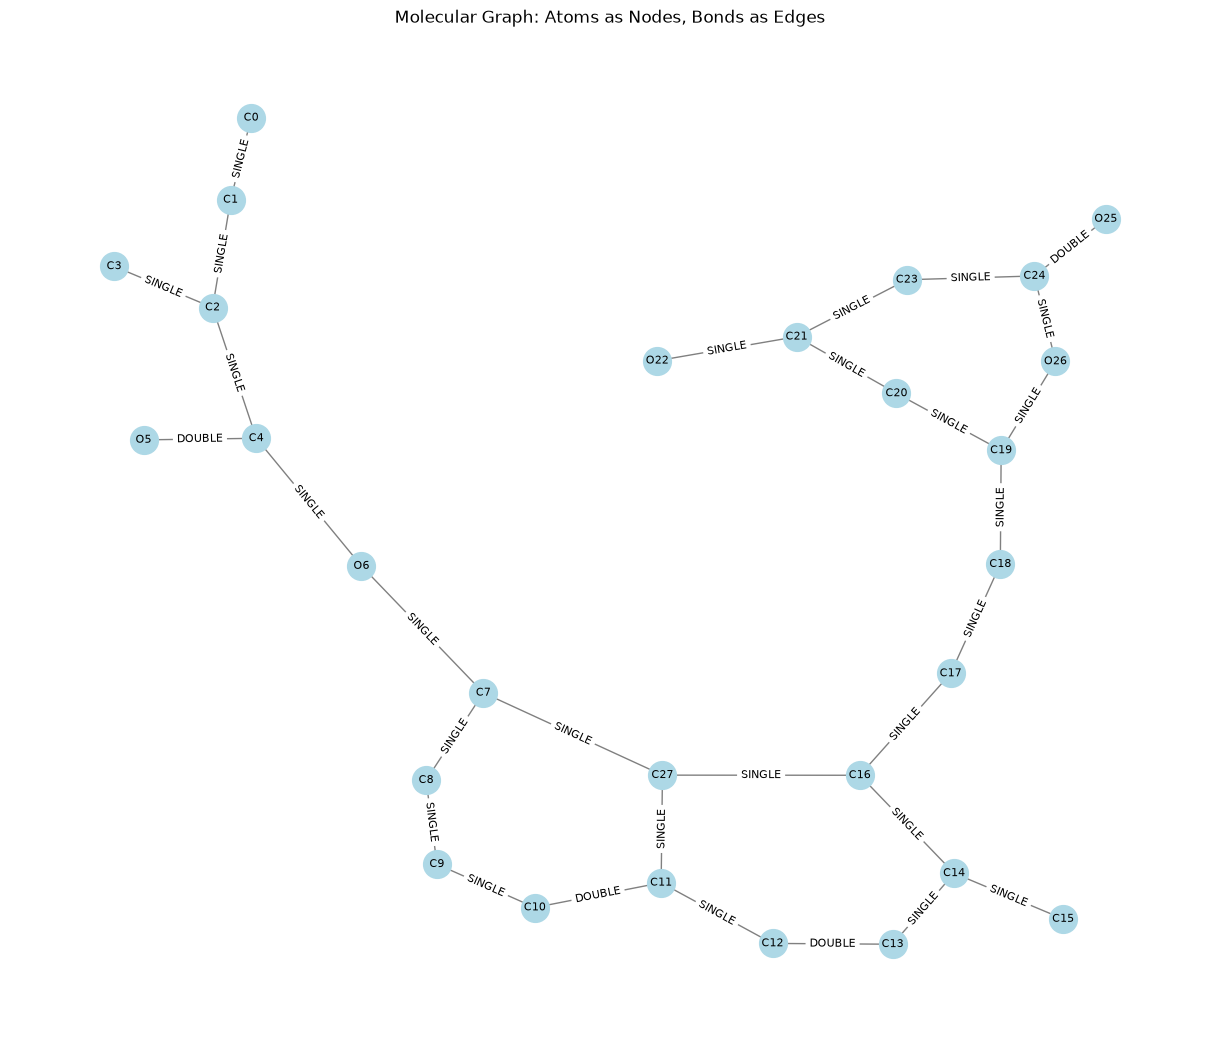

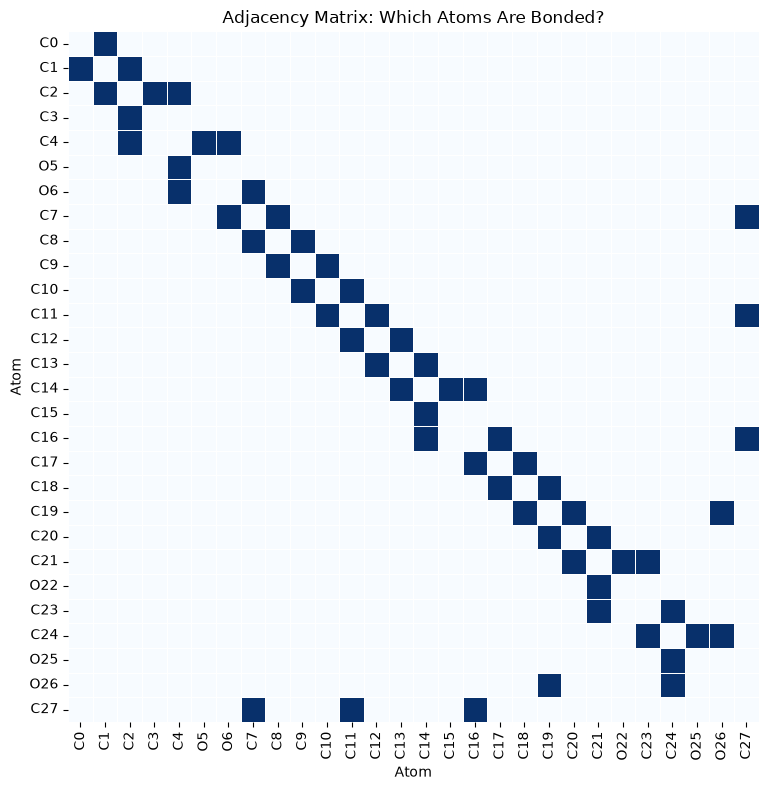

In [73]:
def full_molecule_explainer(df, mol_index, smiles_col="Drug", label_col="Y"):
    smiles = df.iloc[mol_index][smiles_col]
    label = int(df.iloc[mol_index][label_col])
    mol = Chem.MolFromSmiles(smiles)
    features = calculate_molecule_features(smiles)
    
    print("=" * 80)
    print(f"Row index: {mol_index}")
    print(f"SMILES: {smiles}")
    print(f"BBB label: {label}")
    print("=" * 80)
    
    display(Draw.MolToImage(mol, size=(450, 300)))
    
    feature_table = pd.DataFrame(features.items(), columns=["Feature", "Value"])
    display(feature_table)
    
    molecule_card(smiles, label)
    plot_bbb_feature_guide(smiles)
    draw_molecule_with_atom_indices(smiles)
    plot_molecular_graph_with_atom_labels(smiles)
    plot_adjacency_matrix(smiles)


# Try changing this index
full_molecule_explainer(df, mol_index=0)

##### Why look at deterministic molecular features?

Before using a graph neural network, it is helpful to inspect features that are easy to compute and easy to understand.

Examples:

- **Molecular weight**: larger molecules may have more difficulty crossing biological barriers.
- **LogP**: measures hydrophobicity/lipophilicity. BBB penetration often favors moderate lipophilicity.
- **TPSA**: topological polar surface area. Highly polar molecules often cross membranes less easily.
- **H-bond donors and acceptors**: more hydrogen bonding often means stronger interaction with water, which can reduce passive membrane permeability.
- **Rotatable bonds**: flexible molecules may pay a larger entropy penalty when binding or crossing membranes.
- **Rings and aromatic rings**: affect shape, rigidity, and lipophilicity.

A simple model such as logistic regression can use these fixed features directly.

A GNN takes a different approach. It starts with atoms and bonds, then learns molecular representations by passing messages along the graph.

#### Re-train LR and GNN with descriptive features included

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import Descriptors, Lipinski, Crippen, rdMolDescriptors, Draw

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from scipy import sparse

import copy

In [75]:
descriptor_feature_names = [
    "Molecular Weight",
    "LogP",
    "TPSA",
    "H-Bond Donors",
    "H-Bond Acceptors",
    "Rotatable Bonds",
    "Rings",
    "Aromatic Rings",
    "Heavy Atoms",
    "Heteroatoms",
    "Formal Charge",
    "Fraction Csp3"
]


def calculate_molecule_features(smiles):
    """
    Calculate deterministic, human-readable molecular descriptors.
    These features are computed directly from the molecular structure.
    """
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    features = {
        "Molecular Weight": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "H-Bond Donors": Lipinski.NumHDonors(mol),
        "H-Bond Acceptors": Lipinski.NumHAcceptors(mol),
        "Rotatable Bonds": Lipinski.NumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "Aromatic Rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "Heavy Atoms": mol.GetNumHeavyAtoms(),
        "Heteroatoms": rdMolDescriptors.CalcNumHeteroatoms(mol),
        "Formal Charge": Chem.GetFormalCharge(mol),
        "Fraction Csp3": rdMolDescriptors.CalcFractionCSP3(mol),
    }

    return features

In [76]:
rows = []

for idx, row in df.iterrows():
    smiles = row["Drug"]
    y = int(row["Y"])

    mol = Chem.MolFromSmiles(smiles)
    features = calculate_molecule_features(smiles)

    if mol is not None and features is not None:
        new_row = {
            "original_index": idx,
            "Drug": smiles,
            "Y": y
        }
        new_row.update(features)
        rows.append(new_row)

valid_df = pd.DataFrame(rows).reset_index(drop=True)

print(f"Original rows: {len(df)}")
print(f"Valid rows: {len(valid_df)}")

valid_df.head()

Original rows: 406
Valid rows: 406


,original_index,Drug,Y,Molecular Weight,LogP,TPSA,H-Bond Donors,H-Bond Acceptors,Rotatable Bonds,Rings,Aromatic Rings,Heavy Atoms,Heteroatoms,Formal Charge,Fraction Csp3
0,0,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1,390.520,3.94950,72.83,1,5,6,3,0,28,5,0,0.739130
1,1,COc1cc2oc(=O)c(C)c(C)c2cc1OCCCN1CCN(c2ccccc2OC...,1,452.551,4.01814,64.38,0,7,8,4,3,33,7,0,0.423077
2,2,CO[C@@]1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C...,0,520.480,-1.12770,206.30,4,11,9,4,2,36,16,0,0.350000
3,3,c1ccc2c(c1)CCc1cccc3c1C2CN1CCCCC31,1,289.422,4.45770,3.24,0,1,0,5,2,22,1,0,0.428571
4,4,CN(C)CCC1(c2ccccc2)C=Cc2ccccc21,1,263.384,3.95120,3.24,0,1,4,3,2,20,1,0,0.263158


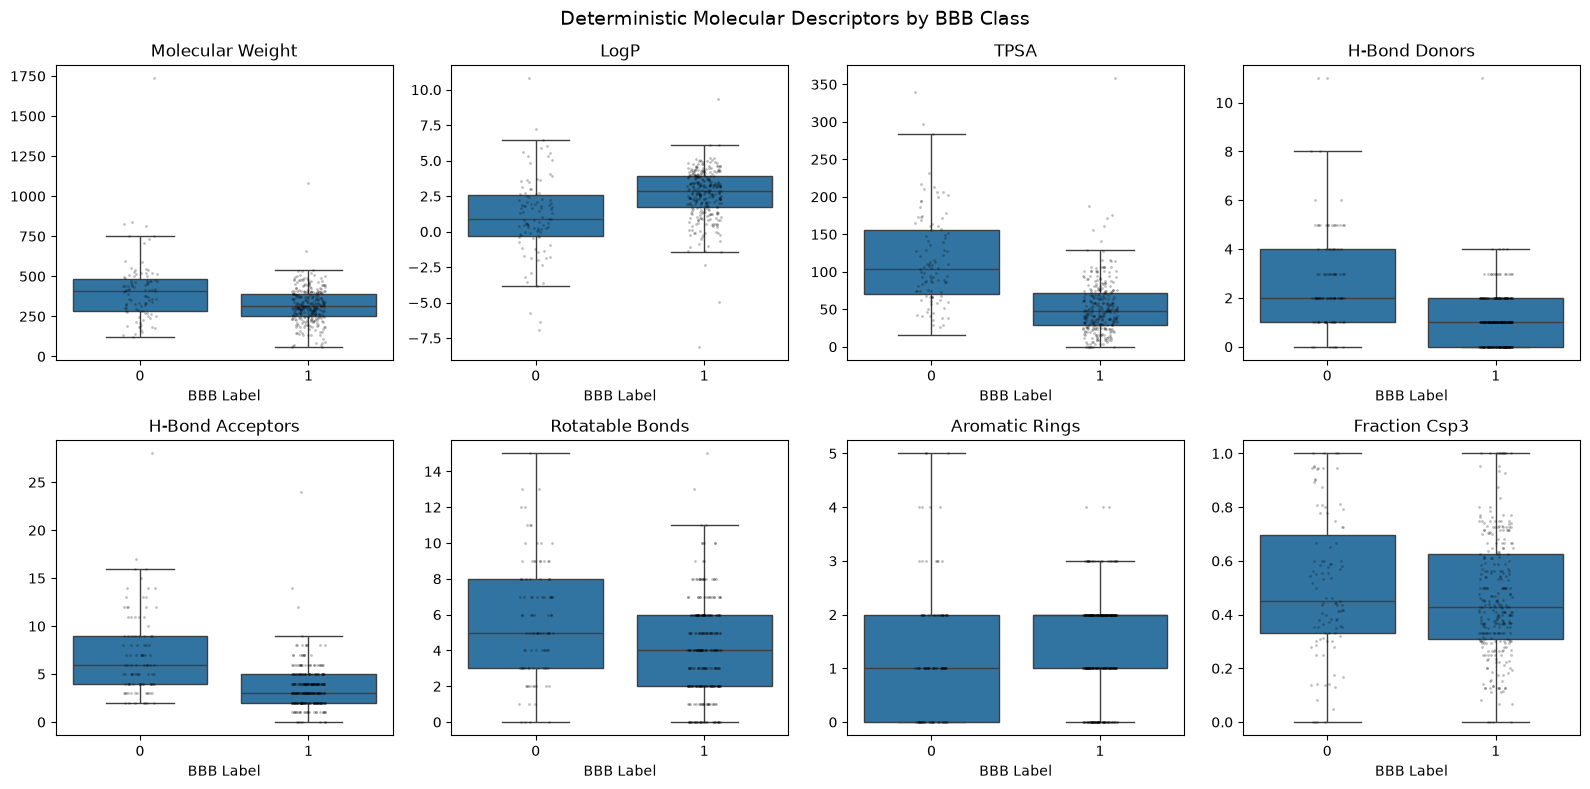

In [77]:
features_to_plot = [
    "Molecular Weight",
    "LogP",
    "TPSA",
    "H-Bond Donors",
    "H-Bond Acceptors",
    "Rotatable Bonds",
    "Aromatic Rings",
    "Fraction Csp3"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

plot_sample = valid_df.sample(min(len(valid_df), 400), random_state=42)

for ax, feature in zip(axes, features_to_plot):
    sns.boxplot(
        data=valid_df,
        x="Y",
        y=feature,
        ax=ax,
        showfliers=False
    )
    sns.stripplot(
        data=plot_sample,
        x="Y",
        y=feature,
        color="black",
        alpha=0.25,
        size=2,
        ax=ax
    )
    ax.set_title(feature)
    ax.set_xlabel("BBB Label")
    ax.set_ylabel("")

plt.suptitle("Deterministic Molecular Descriptors by BBB Class", fontsize=14)
plt.tight_layout()
plt.show()

In [78]:
labels = valid_df["Y"].astype(int).values
indices = np.arange(len(valid_df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.2,
    random_state=42,
    stratify=labels[train_idx]
)

print(f"Train size:      {len(train_idx)}")
print(f"Validation size: {len(val_idx)}")
print(f"Test size:       {len(test_idx)}")

Train size:      259
Validation size: 65
Test size:       82


In [79]:
X_desc_raw = valid_df[descriptor_feature_names].values.astype(float)

desc_scaler = StandardScaler()

X_desc_train_scaled = desc_scaler.fit_transform(X_desc_raw[train_idx])
X_desc_val_scaled = desc_scaler.transform(X_desc_raw[val_idx])
X_desc_test_scaled = desc_scaler.transform(X_desc_raw[test_idx])

# Also create one full scaled descriptor matrix for easy indexing later.
X_desc_scaled = np.zeros_like(X_desc_raw, dtype=float)
X_desc_scaled[train_idx] = X_desc_train_scaled
X_desc_scaled[val_idx] = X_desc_val_scaled
X_desc_scaled[test_idx] = X_desc_test_scaled

print("Scaled descriptor matrix shape:", X_desc_scaled.shape)

Scaled descriptor matrix shape: (406, 12)


##### LR

In [80]:
def smiles_to_morgan_fp(smiles, radius=2, n_bits=2048):
    """
    Convert a SMILES string into a Morgan fingerprint bit vector.
    This is a deterministic molecular fingerprint.
    """
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return np.zeros(n_bits, dtype=np.int8)

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr


n_bits = 2048

X_fp = np.vstack([
    smiles_to_morgan_fp(smi, radius=2, n_bits=n_bits)
    for smi in valid_df["Drug"]
])

print("Morgan fingerprint matrix shape:", X_fp.shape)

Morgan fingerprint matrix shape: (406, 2048)


In [81]:
# Fingerprints are sparse binary vectors.
X_fp_sparse = sparse.csr_matrix(X_fp)

# Descriptors are dense continuous features.
X_desc_sparse = sparse.csr_matrix(X_desc_scaled)

# Combined feature matrix:
# [ Morgan fingerprint bits | scaled descriptors ]
X_combined = sparse.hstack([X_fp_sparse, X_desc_sparse]).tocsr()

y = valid_df["Y"].astype(int).values

X_train_combined = X_combined[train_idx]
X_val_combined = X_combined[val_idx]
X_test_combined = X_combined[test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

print("Combined logistic regression input shape:", X_combined.shape)
print(f"First {n_bits} columns: Morgan fingerprint bits")
print(f"Last {len(descriptor_feature_names)} columns: deterministic descriptors")

Combined logistic regression input shape: (406, 2060)
First 2048 columns: Morgan fingerprint bits
Last 12 columns: deterministic descriptors


In [82]:
logreg_combined = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="saga",
    n_jobs=-1,
    random_state=42
)

logreg_combined.fit(X_train_combined, y_train)

logreg_val_probs = logreg_combined.predict_proba(X_val_combined)[:, 1]
logreg_test_probs = logreg_combined.predict_proba(X_test_combined)[:, 1]

logreg_val_preds = (logreg_val_probs >= 0.5).astype(int)
logreg_test_preds = (logreg_test_probs >= 0.5).astype(int)

print("Validation")
print(f"Accuracy:          {accuracy_score(y_val, logreg_val_preds):.3f}")
print(f"ROC-AUC:           {roc_auc_score(y_val, logreg_val_probs):.3f}")
print(f"Average Precision: {average_precision_score(y_val, logreg_val_probs):.3f}")

print()
print("Test")
print(f"Accuracy:          {accuracy_score(y_test, logreg_test_preds):.3f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, logreg_test_probs):.3f}")
print(f"Average Precision: {average_precision_score(y_test, logreg_test_probs):.3f}")

Validation
Accuracy:          0.769
ROC-AUC:           0.723
Average Precision: 0.863

Test
Accuracy:          0.866
ROC-AUC:           0.908
Average Precision: 0.963


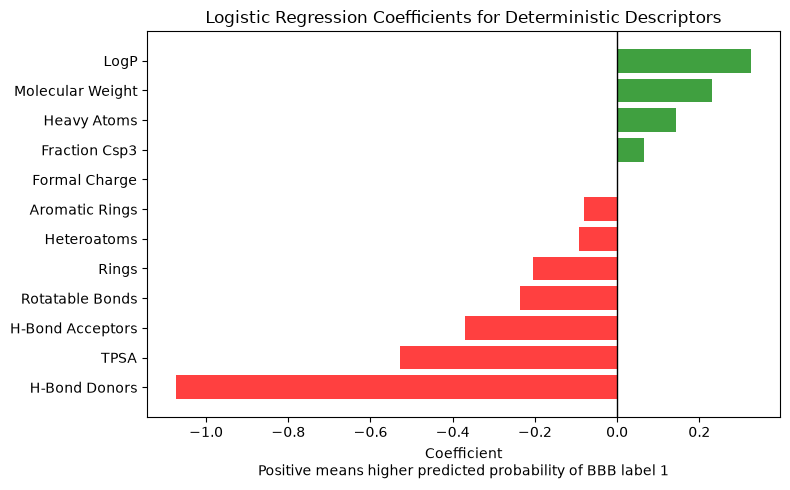

,Descriptor,Coefficient
3,H-Bond Donors,-1.073795
2,TPSA,-0.528643
4,H-Bond Acceptors,-0.369845
5,Rotatable Bonds,-0.235911
6,Rings,-0.204208
9,Heteroatoms,-0.092420
7,Aromatic Rings,-0.080973
10,Formal Charge,0.000000
11,Fraction Csp3,0.065677
8,Heavy Atoms,0.143536


In [83]:
coef = logreg_combined.coef_[0]

# Last columns correspond to deterministic descriptors.
descriptor_coefs = coef[n_bits:]

coef_df = pd.DataFrame({
    "Descriptor": descriptor_feature_names,
    "Coefficient": descriptor_coefs
}).sort_values("Coefficient")

plt.figure(figsize=(8, 5))
colors = ["red" if c < 0 else "green" for c in coef_df["Coefficient"]]

plt.barh(
    coef_df["Descriptor"],
    coef_df["Coefficient"],
    color=colors,
    alpha=0.75
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients for Deterministic Descriptors")
plt.xlabel("Coefficient\nPositive means higher predicted probability of BBB label 1")
plt.tight_layout()
plt.show()

coef_df

In [84]:
# Fingerprint-only model
logreg_fp_only = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="saga",
    n_jobs=-1,
    random_state=42
)

logreg_fp_only.fit(X_fp_sparse[train_idx], y_train)
fp_only_test_probs = logreg_fp_only.predict_proba(X_fp_sparse[test_idx])[:, 1]

# Descriptor-only model
logreg_desc_only = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)

logreg_desc_only.fit(X_desc_scaled[train_idx], y_train)
desc_only_test_probs = logreg_desc_only.predict_proba(X_desc_scaled[test_idx])[:, 1]

comparison_df = pd.DataFrame({
    "Model": [
        "LogReg: Morgan fingerprints only",
        "LogReg: deterministic descriptors only",
        "LogReg: Morgan fingerprints + descriptors"
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, fp_only_test_probs),
        roc_auc_score(y_test, desc_only_test_probs),
        roc_auc_score(y_test, logreg_test_probs)
    ],
    "Test Average Precision": [
        average_precision_score(y_test, fp_only_test_probs),
        average_precision_score(y_test, desc_only_test_probs),
        average_precision_score(y_test, logreg_test_probs)
    ]
})

comparison_df

,Model,Test ROC-AUC,Test Average Precision
0,LogReg: Morgan fingerprints only,0.886027,0.963117
1,LogReg: deterministic descriptors only,0.842311,0.918941
2,LogReg: Morgan fingerprints + descriptors,0.907884,0.963182


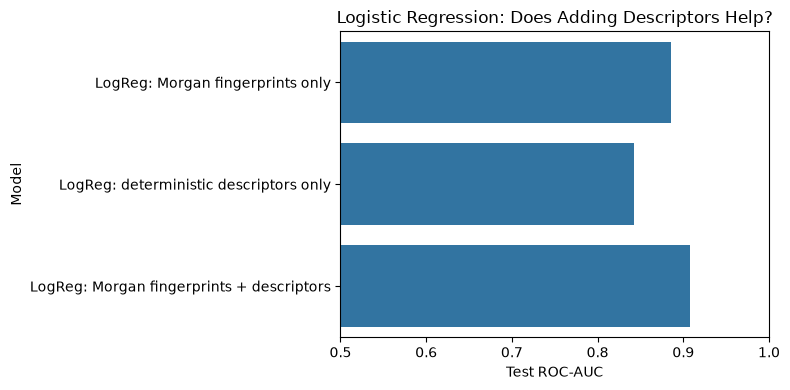

In [86]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=comparison_df,
    x="Test ROC-AUC",
    y="Model"
)
plt.xlim(0.5, 1.0)
plt.title("Logistic Regression: Does Adding Descriptors Help?")
plt.tight_layout()
plt.show()

##### GNN

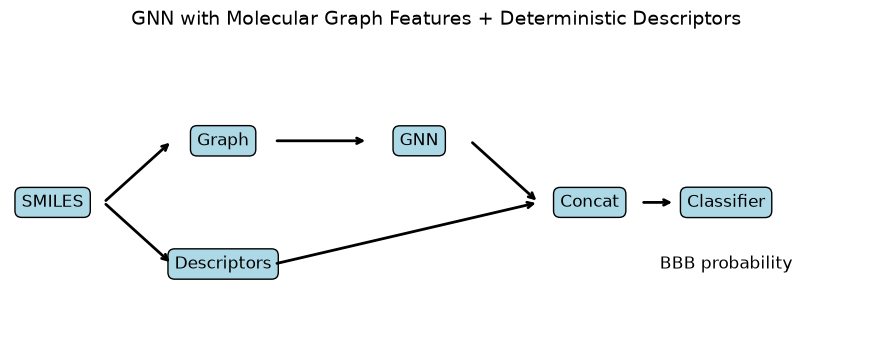

In [190]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")

boxes = {
    "SMILES": (0.05, 0.45),
    "Graph": (0.25, 0.65),
    "Descriptors": (0.25, 0.25),
    "GNN": (0.48, 0.65),
    "Concat": (0.68, 0.45),
    "Classifier": (0.84, 0.45)
}

for text, (x, y_pos) in boxes.items():
    ax.text(
        x, y_pos, text,
        ha="center",
        va="center",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", edgecolor="black")
    )

arrows = [
    ("SMILES", "Graph"),
    ("SMILES", "Descriptors"),
    ("Graph", "GNN"),
    ("GNN", "Concat"),
    ("Descriptors", "Concat"),
    ("Concat", "Classifier")
]

for start, end in arrows:
    x1, y1 = boxes[start]
    x2, y2 = boxes[end]
    ax.annotate(
        "",
        xy=(x2 - 0.06, y2),
        xytext=(x1 + 0.06, y1),
        arrowprops=dict(arrowstyle="->", linewidth=2)
    )

ax.text(
    0.84,
    0.25,
    "BBB probability",
    ha="center",
    va="center",
    fontsize=12
)

plt.title("GNN with Molecular Graph Features + Deterministic Descriptors", fontsize=14)
plt.show()

In [191]:
ATOM_TYPES = [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]
# H, C, N, O, F, P, S, Cl, Br, I

DEGREES = [0, 1, 2, 3, 4, 5]


def one_hot_with_unknown(value, choices):
    return [int(value == choice) for choice in choices]


def atom_features(atom):
    features = []

    # Element identity
    features += one_hot_with_unknown(atom.GetAtomicNum(), ATOM_TYPES)

    # Number of directly bonded neighboring atoms
    features += one_hot_with_unknown(atom.GetDegree(), DEGREES)

    # Other simple atom properties
    features += [
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        int(atom.IsInRing()),
        atom.GetTotalNumHs()
    ]

    return features

In [192]:
def smiles_to_graph_with_descriptors(smiles, y_value, descriptor_vector):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    # Node features
    node_features = []
    for atom in mol.GetAtoms():
        node_features.append(atom_features(atom))

    x = torch.tensor(node_features, dtype=torch.float)

    # Edges
    edge_indices = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Undirected graph: add both directions
        edge_indices += [[i, j], [j, i]]

    if len(edge_indices) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()

    data = Data(
        x=x,
        edge_index=edge_index,
        y=torch.tensor([float(y_value)], dtype=torch.float)
    )

    # Important:
    # Shape is [1, num_descriptors].
    # PyG will batch this into [batch_size, num_descriptors].
    data.desc = torch.tensor(descriptor_vector, dtype=torch.float).view(1, -1)

    data.smiles = smiles

    return data

In [193]:
gnn_data_list = []

for i in range(len(valid_df)):
    smiles_i = valid_df.iloc[i]["Drug"]
    y_i = int(valid_df.iloc[i]["Y"])
    desc_i = X_desc_scaled[i]

    data = smiles_to_graph_with_descriptors(smiles_i, y_i, desc_i)
    gnn_data_list.append(data)

train_data = [gnn_data_list[i] for i in train_idx]
val_data = [gnn_data_list[i] for i in val_idx]
test_data = [gnn_data_list[i] for i in test_idx]

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

num_node_features = gnn_data_list[0].x.shape[1]
num_descriptor_features = gnn_data_list[0].desc.shape[1]

print("Number of atom/node features:", num_node_features)
print("Number of deterministic descriptor features:", num_descriptor_features)

Number of atom/node features: 20
Number of deterministic descriptor features: 12


In [194]:
class MolecularGNNWithDescriptors(nn.Module):
    def __init__(
        self,
        num_node_features,
        num_descriptor_features,
        hidden_dim=16,
        descriptor_hidden_dim=8,
        dropout=0.3
    ):
        super().__init__()

        # Graph pathway
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

        # Descriptor pathway
        # This small neural network lets the model transform scaled descriptors
        # before combining them with the graph embedding.
        self.descriptor_mlp = nn.Sequential(
            nn.Linear(num_descriptor_features, descriptor_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Final classifier after concatenation
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim + descriptor_hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, edge_index, batch, desc, return_embedding=False):
        # -------------------------
        # Graph pathway
        # -------------------------
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        graph_embedding = global_mean_pool(x, batch)

        # -------------------------
        # Descriptor pathway
        # -------------------------
        desc_embedding = self.descriptor_mlp(desc)

        # -------------------------
        # Combine both representations
        # -------------------------
        combined_embedding = torch.cat(
            [graph_embedding, desc_embedding],
            dim=1
        )

        logits = self.classifier(combined_embedding).squeeze(-1)

        if return_embedding:
            return logits, graph_embedding, desc_embedding, combined_embedding

        return logits

In [195]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [196]:
def train_one_epoch_gnn_with_desc(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        logits = model(
            batch.x,
            batch.edge_index,
            batch.batch,
            batch.desc
        )

        y_batch = batch.y.view(-1)

        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_gnn_with_desc(model, loader, criterion=None):
    model.eval()

    all_y = []
    all_probs = []
    all_preds = []
    all_graph_embeddings = []
    all_desc_embeddings = []
    all_combined_embeddings = []

    total_loss = 0

    for batch in loader:
        batch = batch.to(device)

        logits, graph_emb, desc_emb, combined_emb = model(
            batch.x,
            batch.edge_index,
            batch.batch,
            batch.desc,
            return_embedding=True
        )

        y_batch = batch.y.view(-1)

        if criterion is not None:
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * batch.num_graphs

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        all_y.append(y_batch.cpu())
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_graph_embeddings.append(graph_emb.cpu())
        all_desc_embeddings.append(desc_emb.cpu())
        all_combined_embeddings.append(combined_emb.cpu())

    all_y = torch.cat(all_y).numpy()
    all_probs = torch.cat(all_probs).numpy()
    all_preds = torch.cat(all_preds).numpy()

    all_graph_embeddings = torch.cat(all_graph_embeddings).numpy()
    all_desc_embeddings = torch.cat(all_desc_embeddings).numpy()
    all_combined_embeddings = torch.cat(all_combined_embeddings).numpy()

    metrics = {}

    if criterion is not None:
        metrics["loss"] = total_loss / len(loader.dataset)

    metrics["accuracy"] = accuracy_score(all_y, all_preds)

    if len(np.unique(all_y)) > 1:
        metrics["roc_auc"] = roc_auc_score(all_y, all_probs)
        metrics["average_precision"] = average_precision_score(all_y, all_probs)
    else:
        metrics["roc_auc"] = np.nan
        metrics["average_precision"] = np.nan

    return {
        "y": all_y,
        "probs": all_probs,
        "preds": all_preds,
        "graph_embeddings": all_graph_embeddings,
        "desc_embeddings": all_desc_embeddings,
        "combined_embeddings": all_combined_embeddings,
        "metrics": metrics
    }

In [206]:
model_gnn_desc = MolecularGNNWithDescriptors(
    num_node_features=num_node_features,
    num_descriptor_features=num_descriptor_features,
    hidden_dim=32,
    descriptor_hidden_dim=8,
    dropout=0.2
).to(device)

train_labels = labels[train_idx]
num_pos = train_labels.sum()
num_neg = len(train_labels) - num_pos

pos_weight = torch.tensor(
    [num_neg / max(num_pos, 1)],
    dtype=torch.float
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model_gnn_desc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print(model_gnn_desc)

MolecularGNNWithDescriptors(
  (conv1): GCNConv(20, 32)
  (conv2): GCNConv(32, 32)
  (descriptor_mlp): Sequential(
    (0): Linear(in_features=12, out_features=8, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=40, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [239]:
history = []

best_val_auc = -np.inf
best_model_state = copy.deepcopy(model_gnn_desc.state_dict())

num_epochs = 35

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch_gnn_with_desc(
        model_gnn_desc,
        train_loader,
        optimizer,
        criterion
    )

    val_results = evaluate_gnn_with_desc(
        model_gnn_desc,
        val_loader,
        criterion
    )

    val_metrics = val_results["metrics"]

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_average_precision": val_metrics["average_precision"]
    }

    history.append(row)

    if not np.isnan(val_metrics["roc_auc"]):
        if val_metrics["roc_auc"] > best_val_auc:
            best_val_auc = val_metrics["roc_auc"]
            best_model_state = copy.deepcopy(model_gnn_desc.state_dict())

    if epoch % 1 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val ROC-AUC: {val_metrics['roc_auc']:.4f}"
        )

history_df = pd.DataFrame(history)

# Load best validation model before test evaluation
model_gnn_desc.load_state_dict(best_model_state)

Epoch 001 | Train Loss: 0.3395 | Val Loss: 0.3345 | Val ROC-AUC: 0.7985
Epoch 002 | Train Loss: 0.3376 | Val Loss: 0.3327 | Val ROC-AUC: 0.8048
Epoch 003 | Train Loss: 0.3359 | Val Loss: 0.3301 | Val ROC-AUC: 0.8010
Epoch 004 | Train Loss: 0.3332 | Val Loss: 0.3276 | Val ROC-AUC: 0.8023
Epoch 005 | Train Loss: 0.3345 | Val Loss: 0.3247 | Val ROC-AUC: 0.8036
Epoch 006 | Train Loss: 0.3233 | Val Loss: 0.3210 | Val ROC-AUC: 0.8010
Epoch 007 | Train Loss: 0.3260 | Val Loss: 0.3176 | Val ROC-AUC: 0.8036
Epoch 008 | Train Loss: 0.3240 | Val Loss: 0.3145 | Val ROC-AUC: 0.8010
Epoch 009 | Train Loss: 0.3186 | Val Loss: 0.3105 | Val ROC-AUC: 0.7959
Epoch 010 | Train Loss: 0.3159 | Val Loss: 0.3070 | Val ROC-AUC: 0.7883
Epoch 011 | Train Loss: 0.3155 | Val Loss: 0.3050 | Val ROC-AUC: 0.7844
Epoch 012 | Train Loss: 0.3060 | Val Loss: 0.3021 | Val ROC-AUC: 0.7781
Epoch 013 | Train Loss: 0.2993 | Val Loss: 0.2993 | Val ROC-AUC: 0.7742
Epoch 014 | Train Loss: 0.3045 | Val Loss: 0.2975 | Val ROC-AUC:

<All keys matched successfully>

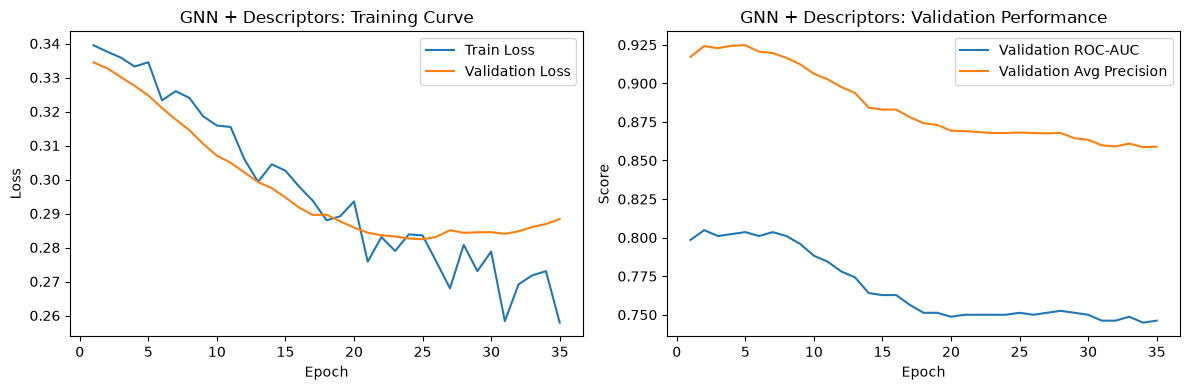

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("GNN + Descriptors: Training Curve")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_roc_auc"], label="Validation ROC-AUC")
axes[1].plot(history_df["epoch"], history_df["val_average_precision"], label="Validation Avg Precision")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("GNN + Descriptors: Validation Performance")
axes[1].legend()

plt.tight_layout()
plt.show()

In [241]:
gnn_desc_test_results = evaluate_gnn_with_desc(
    model_gnn_desc,
    test_loader,
    criterion
)

print("GNN + deterministic descriptors test metrics")
for k, v in gnn_desc_test_results["metrics"].items():
    print(f"{k}: {v:.3f}")

GNN + deterministic descriptors test metrics
loss: 0.331
accuracy: 0.780
roc_auc: 0.810
average_precision: 0.915


##### Compare LR and GNN Results

In [242]:
gnn_desc_test_y = gnn_desc_test_results["y"]
gnn_desc_test_probs = gnn_desc_test_results["probs"]
gnn_desc_test_preds = gnn_desc_test_results["preds"]

combined_model_comparison = pd.DataFrame({
    "Model": [
        "LogReg: Morgan fingerprints + descriptors",
        "GNN: molecular graph + descriptors"
    ],
    "Test Accuracy": [
        accuracy_score(y_test, logreg_test_preds),
        accuracy_score(gnn_desc_test_y, gnn_desc_test_preds)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, logreg_test_probs),
        roc_auc_score(gnn_desc_test_y, gnn_desc_test_probs)
    ],
    "Test Average Precision": [
        average_precision_score(y_test, logreg_test_probs),
        average_precision_score(gnn_desc_test_y, gnn_desc_test_probs)
    ]
})

combined_model_comparison

,Model,Test Accuracy,Test ROC-AUC,Test Average Precision
0,LogReg: Morgan fingerprints + descriptors,0.780488,0.887588,0.963380
1,GNN: molecular graph + descriptors,0.780488,0.810304,0.914954


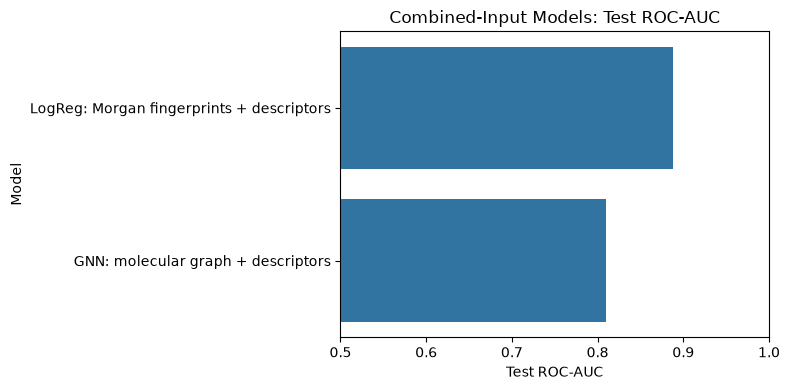

In [243]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=combined_model_comparison,
    x="Test ROC-AUC",
    y="Model"
)
plt.xlim(0.5, 1.0)
plt.title("Combined-Input Models: Test ROC-AUC")
plt.tight_layout()
plt.show()

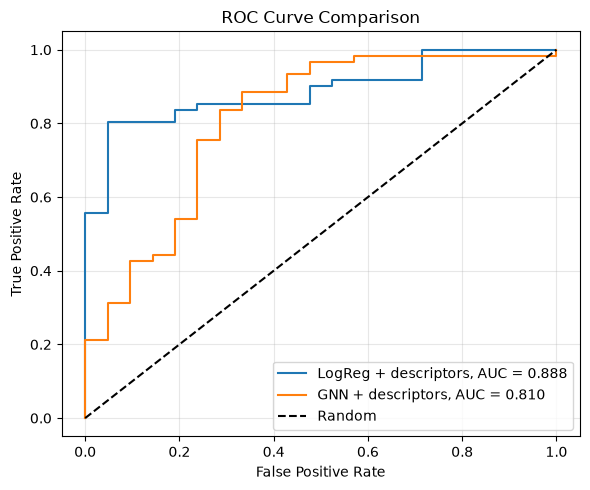

In [244]:
logreg_fpr, logreg_tpr, _ = roc_curve(y_test, logreg_test_probs)
gnn_fpr, gnn_tpr, _ = roc_curve(gnn_desc_test_y, gnn_desc_test_probs)

logreg_auc = roc_auc_score(y_test, logreg_test_probs)
gnn_auc = roc_auc_score(gnn_desc_test_y, gnn_desc_test_probs)

plt.figure(figsize=(6, 5))

plt.plot(
    logreg_fpr,
    logreg_tpr,
    label=f"LogReg + descriptors, AUC = {logreg_auc:.3f}"
)

plt.plot(
    gnn_fpr,
    gnn_tpr,
    label=f"GNN + descriptors, AUC = {gnn_auc:.3f}"
)

plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

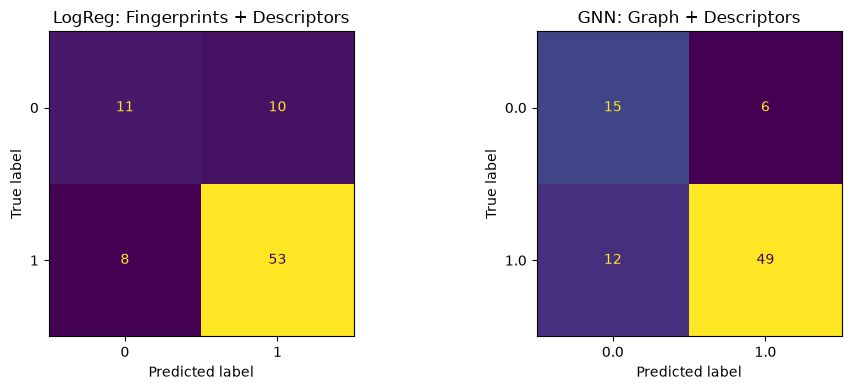

In [245]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logreg_test_preds,
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("LogReg: Fingerprints + Descriptors")

ConfusionMatrixDisplay.from_predictions(
    gnn_desc_test_y,
    gnn_desc_test_preds,
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("GNN: Graph + Descriptors")

plt.tight_layout()
plt.show()

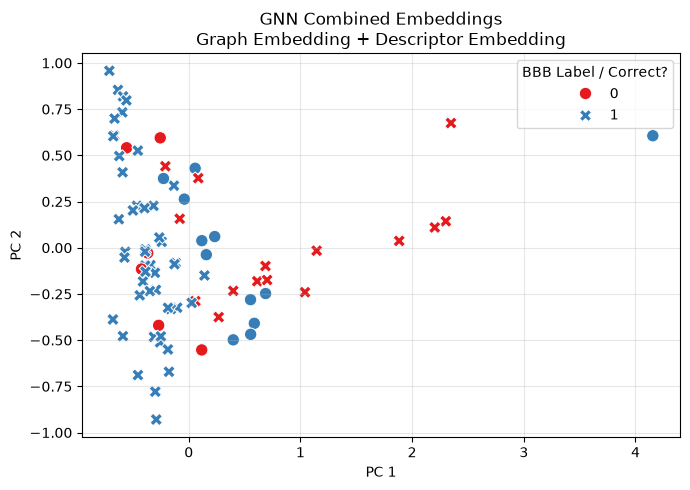

In [247]:
from sklearn.decomposition import PCA

combined_embeddings = gnn_desc_test_results["combined_embeddings"]
test_labels = gnn_desc_test_results["y"].astype(int)
test_correct = gnn_desc_test_results["preds"] == test_labels
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(combined_embeddings)

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=emb_2d[:, 0],
    y=emb_2d[:, 1],
    hue=test_labels,
    style=test_correct,
    palette="Set1",
    s=80
)

plt.title("GNN Combined Embeddings\nGraph Embedding + Descriptor Embedding")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="BBB Label / Correct?")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
##### Why adding deterministic descriptors may help
Adding deterministic descriptors can help because they provide the model with chemically meaningful information that may be difficult to learn from a small dataset.

For BBB prediction, features like these are relevant:

**Molecular Weight**
- Smaller molecules often cross biological barriers more easily.

**LogP**
- BBB penetration is often related to lipophilicity. Molecules that are too polar may struggle to cross membranes.

**TPSA**
- Topological polar surface area is strongly related to membrane permeability.

**H-bond donors/acceptors**
- Molecules with many hydrogen bonding groups often interact strongly with water, which can reduce passive permeability.

**Rotatable bonds**
- Flexibility can affect permeability and binding.

So, deterministic descriptors can act like useful “chemistry hints.”

---

##### Why adding deterministic descriptors may not help
Adding these features is not guaranteed to improve performance.

Reasons include:

**Redundant information**
- The Morgan fingerprint or GNN may already encode similar information. For example, atom types and connectivity often imply molecular size, rings, heteroatoms, and aromaticity.

**Small dataset overfitting**
- More features can sometimes make a model fit noise instead of general patterns.

**Descriptors are incomplete**
- Simple descriptors do not capture everything important for BBB permeability, such as:
  - 3D shape
  - ionization state at physiological pH
  - transporter interactions
  - metabolism
  - active efflux mechanisms


**Scaling and calibration matter**
- Descriptors like molecular weight and formal charge live on very different numerical scales. This is why we standardized them before use.

**The GNN may lean too heavily on shortcuts**
- If descriptors are strongly correlated with labels in the training set, the model may ignore graph structure and perform worse on new chemical space.
---

#### Improving GNN

The current GNN likely has several disadvantages:

**Too-simple atom features**
- If atoms only have atomic number and degree, the GNN is missing aromaticity, charge, ring membership, hybridization, hydrogens, etc.

**No bond features**
- The original GCN only knows that two atoms are connected. It does not know whether the bond is single, double, aromatic, conjugated, or in a ring.

**GCNConv is generic**
- GCNConv was not designed specifically for molecular chemistry. Models like GIN/GINE are often stronger for molecular graphs.

**Small dataset problem**
- GNNs usually need more data than logistic regression. Morgan fingerprints already encode lots of chemistry by design.

**Pooling may be too simple**
- global_mean_pool can wash out important substructures. Combining mean, max, and sum pooling often works better.

**Training needs more care**
- GNNs are sensitive to learning rate, dropout, weight decay, batch norm, early stopping, and random seed.

In [273]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen, rdMolDescriptors

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GINEConv,
    BatchNorm,
    global_mean_pool,
    global_max_pool,
    global_add_pool
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [274]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # These help reproducibility, though full determinism is not always guaranteed on GPU.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [275]:
descriptor_feature_names = [
    "Molecular Weight",
    "LogP",
    "TPSA",
    "H-Bond Donors",
    "H-Bond Acceptors",
    "Rotatable Bonds",
    "Rings",
    "Aromatic Rings",
    "Heavy Atoms",
    "Heteroatoms",
    "Formal Charge",
    "Fraction Csp3"
]


def calculate_molecule_features(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return {
        "Molecular Weight": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "H-Bond Donors": Lipinski.NumHDonors(mol),
        "H-Bond Acceptors": Lipinski.NumHAcceptors(mol),
        "Rotatable Bonds": Lipinski.NumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "Aromatic Rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "Heavy Atoms": mol.GetNumHeavyAtoms(),
        "Heteroatoms": rdMolDescriptors.CalcNumHeteroatoms(mol),
        "Formal Charge": Chem.GetFormalCharge(mol),
        "Fraction Csp3": rdMolDescriptors.CalcFractionCSP3(mol),
    }

In [276]:
rows = []

for idx, row in df.iterrows():
    smiles = row["Drug"]
    y = int(row["Y"])

    mol = Chem.MolFromSmiles(smiles)
    feats = calculate_molecule_features(smiles)

    if mol is not None and feats is not None:
        new_row = {
            "original_index": idx,
            "Drug": smiles,
            "Y": y
        }
        new_row.update(feats)
        rows.append(new_row)

valid_df = pd.DataFrame(rows).reset_index(drop=True)

print(f"Original rows: {len(df)}")
print(f"Valid molecules: {len(valid_df)}")

valid_df.head()

Original rows: 406
Valid molecules: 406


,original_index,Drug,Y,Molecular Weight,LogP,TPSA,H-Bond Donors,H-Bond Acceptors,Rotatable Bonds,Rings,Aromatic Rings,Heavy Atoms,Heteroatoms,Formal Charge,Fraction Csp3
0,0,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1,390.520,3.94950,72.83,1,5,6,3,0,28,5,0,0.739130
1,1,COc1cc2oc(=O)c(C)c(C)c2cc1OCCCN1CCN(c2ccccc2OC...,1,452.551,4.01814,64.38,0,7,8,4,3,33,7,0,0.423077
2,2,CO[C@@]1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C...,0,520.480,-1.12770,206.30,4,11,9,4,2,36,16,0,0.350000
3,3,c1ccc2c(c1)CCc1cccc3c1C2CN1CCCCC31,1,289.422,4.45770,3.24,0,1,0,5,2,22,1,0,0.428571
4,4,CN(C)CCC1(c2ccccc2)C=Cc2ccccc21,1,263.384,3.95120,3.24,0,1,4,3,2,20,1,0,0.263158


In [277]:
labels = valid_df["Y"].astype(int).values
indices = np.arange(len(valid_df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.2,
    random_state=42,
    stratify=labels[train_idx]
)

print(f"Train: {len(train_idx)}")
print(f"Validation: {len(val_idx)}")
print(f"Test: {len(test_idx)}")

Train: 259
Validation: 65
Test: 82


In [278]:
X_desc_raw = valid_df[descriptor_feature_names].values.astype(float)

desc_scaler = StandardScaler()

X_desc_scaled = np.zeros_like(X_desc_raw, dtype=float)
X_desc_scaled[train_idx] = desc_scaler.fit_transform(X_desc_raw[train_idx])
X_desc_scaled[val_idx] = desc_scaler.transform(X_desc_raw[val_idx])
X_desc_scaled[test_idx] = desc_scaler.transform(X_desc_raw[test_idx])

print("Descriptor matrix shape:", X_desc_scaled.shape)

Descriptor matrix shape: (406, 12)


In [279]:
ATOM_TYPES = [1, 5, 6, 7, 8, 9, 14, 15, 16, 17, 35, 53]
# H, B, C, N, O, F, Si, P, S, Cl, Br, I

DEGREES = [0, 1, 2, 3, 4, 5, 6]
FORMAL_CHARGES = [-2, -1, 0, 1, 2]
HYBRIDIZATIONS = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2
]


def one_hot_with_unknown(value, choices):
    """
    One-hot encode value.
    If value is not in choices, all zeros are used.
    """
    return [int(value == choice) for choice in choices]


def atom_features(atom):
    features = []

    # Element identity
    features += one_hot_with_unknown(atom.GetAtomicNum(), ATOM_TYPES)

    # Local connectivity
    features += one_hot_with_unknown(atom.GetDegree(), DEGREES)

    # Formal charge
    features += one_hot_with_unknown(atom.GetFormalCharge(), FORMAL_CHARGES)

    # Hybridization
    features += one_hot_with_unknown(atom.GetHybridization(), HYBRIDIZATIONS)

    # Binary/numeric atom properties
    features += [
        int(atom.GetIsAromatic()),
        int(atom.IsInRing()),
        atom.GetTotalNumHs(),
        int(atom.GetChiralTag() != Chem.rdchem.ChiralType.CHI_UNSPECIFIED)
    ]

    return features

In [280]:
BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC
]

STEREO_TYPES = [
    Chem.rdchem.BondStereo.STEREONONE,
    Chem.rdchem.BondStereo.STEREOANY,
    Chem.rdchem.BondStereo.STEREOZ,
    Chem.rdchem.BondStereo.STEREOE
]


def bond_features(bond):
    features = []

    # Bond type
    features += one_hot_with_unknown(bond.GetBondType(), BOND_TYPES)

    # Bond properties
    features += [
        int(bond.GetIsConjugated()),
        int(bond.IsInRing())
    ]

    # Stereo
    features += one_hot_with_unknown(bond.GetStereo(), STEREO_TYPES)

    return features

In [281]:
def smiles_to_graph_with_edges_and_descriptors(smiles, y_value, descriptor_vector):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    # Atom/node features
    x = torch.tensor(
        [atom_features(atom) for atom in mol.GetAtoms()],
        dtype=torch.float
    )

    # Bond/edge features
    edge_indices = []
    edge_attrs = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        bf = bond_features(bond)

        # Undirected graph: add both directions
        edge_indices.append([i, j])
        edge_indices.append([j, i])

        edge_attrs.append(bf)
        edge_attrs.append(bf)

    if len(edge_indices) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, len(bond_features_dummy)), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attrs, dtype=torch.float)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=torch.tensor([float(y_value)], dtype=torch.float)
    )

    data.desc = torch.tensor(descriptor_vector, dtype=torch.float).view(1, -1)
    data.smiles = smiles

    return data

In [282]:
# Determine bond feature length using a simple example bond
example_bond_mol = Chem.MolFromSmiles("CC")
example_bond = example_bond_mol.GetBondWithIdx(0)
bond_features_dummy = bond_features(example_bond)

num_bond_features = len(bond_features_dummy)
num_bond_features

10

In [283]:
gnn_data_list = []

for i in range(len(valid_df)):
    smiles_i = valid_df.iloc[i]["Drug"]
    y_i = int(valid_df.iloc[i]["Y"])
    desc_i = X_desc_scaled[i]

    data = smiles_to_graph_with_edges_and_descriptors(
        smiles_i,
        y_i,
        desc_i
    )

    if data is not None:
        gnn_data_list.append(data)

train_data = [gnn_data_list[i] for i in train_idx]
val_data = [gnn_data_list[i] for i in val_idx]
test_data = [gnn_data_list[i] for i in test_idx]

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

num_node_features = gnn_data_list[0].x.shape[1]
num_edge_features = gnn_data_list[0].edge_attr.shape[1]
num_descriptor_features = gnn_data_list[0].desc.shape[1]

print("Node feature dim:", num_node_features)
print("Edge feature dim:", num_edge_features)
print("Descriptor feature dim:", num_descriptor_features)

Node feature dim: 33
Edge feature dim: 10
Descriptor feature dim: 12


In [284]:
class BetterMolecularGNN(nn.Module):
    def __init__(
        self,
        num_node_features,
        num_edge_features,
        num_descriptor_features,
        hidden_dim=128,
        descriptor_hidden_dim=64,
        num_layers=4,
        dropout=0.25
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.dropout = dropout

        # Encode raw atom features into hidden dimension
        self.atom_encoder = nn.Linear(num_node_features, hidden_dim)

        # GINE convolution layers
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )

            conv = GINEConv(
                nn=mlp,
                edge_dim=num_edge_features,
                train_eps=True
            )

            self.convs.append(conv)
            self.norms.append(BatchNorm(hidden_dim))

        # Descriptor pathway
        self.descriptor_mlp = nn.Sequential(
            nn.Linear(num_descriptor_features, descriptor_hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(descriptor_hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(descriptor_hidden_dim, descriptor_hidden_dim),
            nn.ReLU()
        )

        # We concatenate mean, max, and sum pooling
        pooled_dim = hidden_dim * 3

        combined_dim = pooled_dim + descriptor_hidden_dim

        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, edge_attr, batch, desc, return_embedding=False):
        x = self.atom_encoder(x)

        for conv, norm in zip(self.convs, self.norms):
            residual = x

            x = conv(x, edge_index, edge_attr)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

            # Residual connection helps deeper GNN training
            x = x + residual

        # Multiple pooling operations capture different molecule-level summaries
        mean_pool = global_mean_pool(x, batch)
        max_pool = global_max_pool(x, batch)
        add_pool = global_add_pool(x, batch)

        graph_embedding = torch.cat(
            [mean_pool, max_pool, add_pool],
            dim=1
        )

        desc_embedding = self.descriptor_mlp(desc)

        combined_embedding = torch.cat(
            [graph_embedding, desc_embedding],
            dim=1
        )

        logits = self.classifier(combined_embedding).squeeze(-1)

        if return_embedding:
            return logits, graph_embedding, desc_embedding, combined_embedding

        return logits

In [285]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        logits = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch,
            batch.desc
        )

        y = batch.y.view(-1)

        loss = criterion(logits, y)
        loss.backward()

        # Gradient clipping can stabilize GNN training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()

    all_y = []
    all_probs = []
    all_preds = []
    all_embeddings = []

    total_loss = 0

    for batch in loader:
        batch = batch.to(device)

        logits, graph_emb, desc_emb, combined_emb = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch,
            batch.desc,
            return_embedding=True
        )

        y = batch.y.view(-1)

        if criterion is not None:
            loss = criterion(logits, y)
            total_loss += loss.item() * batch.num_graphs

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        all_y.append(y.cpu())
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_embeddings.append(combined_emb.cpu())

    all_y = torch.cat(all_y).numpy()
    all_probs = torch.cat(all_probs).numpy()
    all_preds = torch.cat(all_preds).numpy()
    all_embeddings = torch.cat(all_embeddings).numpy()

    metrics = {}

    if criterion is not None:
        metrics["loss"] = total_loss / len(loader.dataset)

    metrics["accuracy"] = accuracy_score(all_y, all_preds)
    metrics["f1"] = f1_score(all_y, all_preds)

    if len(np.unique(all_y)) > 1:
        metrics["roc_auc"] = roc_auc_score(all_y, all_probs)
        metrics["average_precision"] = average_precision_score(all_y, all_probs)
    else:
        metrics["roc_auc"] = np.nan
        metrics["average_precision"] = np.nan

    return {
        "y": all_y,
        "probs": all_probs,
        "preds": all_preds,
        "embeddings": all_embeddings,
        "metrics": metrics
    }

In [293]:
set_seed(42)

model = BetterMolecularGNN(
    num_node_features=num_node_features,
    num_edge_features=num_edge_features,
    num_descriptor_features=num_descriptor_features,
    hidden_dim=24,
    descriptor_hidden_dim=8,
    num_layers=3,
    dropout=0.3
).to(device)

train_labels = labels[train_idx]
num_pos = train_labels.sum()
num_neg = len(train_labels) - num_pos

pos_weight = torch.tensor(
    [num_neg / max(num_pos, 1)],
    dtype=torch.float
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=10
)

print(model)

BetterMolecularGNN(
  (atom_encoder): Linear(in_features=33, out_features=24, bias=True)
  (convs): ModuleList(
    (0-2): 3 x GINEConv(nn=Sequential(
      (0): Linear(in_features=24, out_features=24, bias=True)
      (1): ReLU()
      (2): Linear(in_features=24, out_features=24, bias=True)
    ))
  )
  (norms): ModuleList(
    (0-2): 3 x BatchNorm(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (descriptor_mlp): Sequential(
    (0): Linear(in_features=12, out_features=8, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=80, out_features=24, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)

In [294]:
history = []

best_val_auc = -np.inf
best_state = copy.deepcopy(model.state_dict())

patience = 500
epochs_without_improvement = 0

num_epochs = 100

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_results = evaluate(
        model,
        val_loader,
        criterion
    )

    val_metrics = val_results["metrics"]
    val_auc = val_metrics["roc_auc"]

    scheduler.step(val_auc)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_average_precision": val_metrics["average_precision"],
        "lr": optimizer.param_groups[0]["lr"]
    }

    history.append(row)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 1 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val AUC: {val_auc:.4f} | "
            f"Val AP: {val_metrics['average_precision']:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.6f}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

history_df = pd.DataFrame(history)

model.load_state_dict(best_state)

print(f"Best validation ROC-AUC: {best_val_auc:.4f}")

Epoch 001 | Train Loss: 0.3723 | Val Loss: 0.3562 | Val AUC: 0.3737 | Val AP: 0.7014 | LR: 0.000500
Epoch 002 | Train Loss: 0.3615 | Val Loss: 0.3527 | Val AUC: 0.5191 | Val AP: 0.7894 | LR: 0.000500
Epoch 003 | Train Loss: 0.3626 | Val Loss: 0.3555 | Val AUC: 0.4872 | Val AP: 0.7641 | LR: 0.000500
Epoch 004 | Train Loss: 0.3614 | Val Loss: 0.3518 | Val AUC: 0.5434 | Val AP: 0.8052 | LR: 0.000500
Epoch 005 | Train Loss: 0.3571 | Val Loss: 0.3467 | Val AUC: 0.6454 | Val AP: 0.8621 | LR: 0.000500
Epoch 006 | Train Loss: 0.3520 | Val Loss: 0.3438 | Val AUC: 0.7143 | Val AP: 0.8829 | LR: 0.000500
Epoch 007 | Train Loss: 0.3520 | Val Loss: 0.3431 | Val AUC: 0.6913 | Val AP: 0.8682 | LR: 0.000500
Epoch 008 | Train Loss: 0.3462 | Val Loss: 0.3396 | Val AUC: 0.7245 | Val AP: 0.8742 | LR: 0.000500
Epoch 009 | Train Loss: 0.3396 | Val Loss: 0.3390 | Val AUC: 0.6760 | Val AP: 0.8567 | LR: 0.000500
Epoch 010 | Train Loss: 0.3429 | Val Loss: 0.3372 | Val AUC: 0.6747 | Val AP: 0.8596 | LR: 0.000500


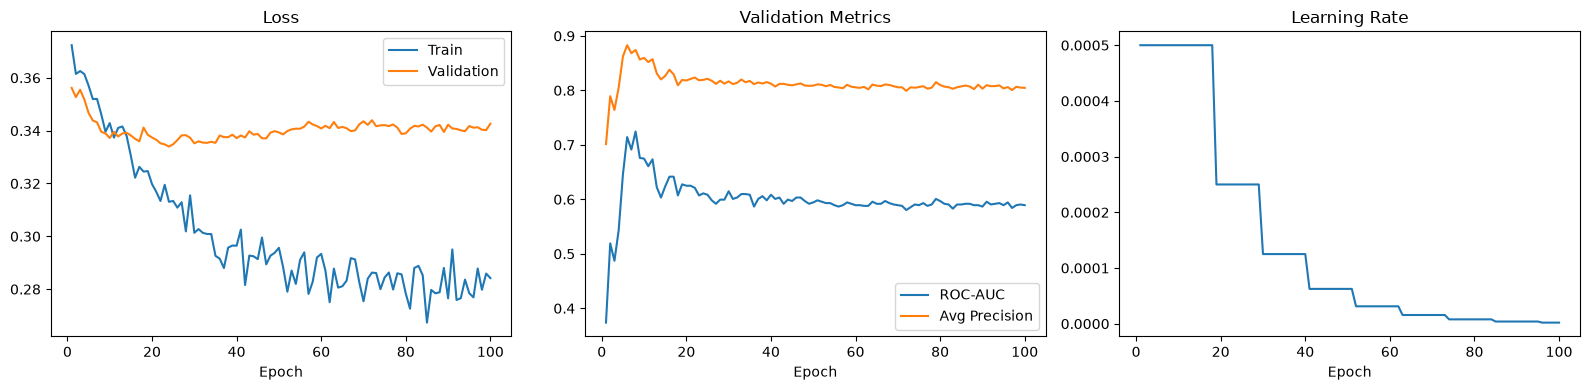

In [295]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_roc_auc"], label="ROC-AUC")
axes[1].plot(history_df["epoch"], history_df["val_average_precision"], label="Avg Precision")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["lr"])
axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

Best threshold by F1:       0.50
Best threshold by accuracy: 0.50


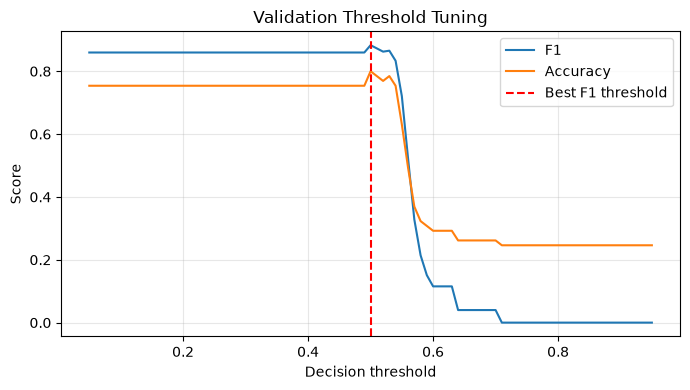

In [296]:
val_results = evaluate(model, val_loader, criterion)

val_y = val_results["y"]
val_probs = val_results["probs"]

thresholds = np.linspace(0.05, 0.95, 91)

threshold_rows = []

for threshold in thresholds:
    preds = (val_probs >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(val_y, preds),
        "f1": f1_score(val_y, preds)
    })

threshold_df = pd.DataFrame(threshold_rows)

best_threshold_f1 = threshold_df.sort_values("f1", ascending=False).iloc[0]["threshold"]
best_threshold_acc = threshold_df.sort_values("accuracy", ascending=False).iloc[0]["threshold"]

print(f"Best threshold by F1:       {best_threshold_f1:.2f}")
print(f"Best threshold by accuracy: {best_threshold_acc:.2f}")

plt.figure(figsize=(7, 4))
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="Accuracy")
plt.axvline(best_threshold_f1, color="red", linestyle="--", label="Best F1 threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Validation Threshold Tuning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [297]:
test_results = evaluate(model, test_loader, criterion)

test_y = test_results["y"]
test_probs = test_results["probs"]

# Use threshold chosen on validation set
chosen_threshold = best_threshold_f1

test_preds = (test_probs >= chosen_threshold).astype(int)

print("Improved GNN test metrics")
print(f"Threshold:         {chosen_threshold:.2f}")
print(f"Accuracy:          {accuracy_score(test_y, test_preds):.3f}")
print(f"F1:                {f1_score(test_y, test_preds):.3f}")
print(f"ROC-AUC:           {roc_auc_score(test_y, test_probs):.3f}")
print(f"Average Precision: {average_precision_score(test_y, test_probs):.3f}")

Improved GNN test metrics
Threshold:         0.50
Accuracy:          0.768
F1:                0.865
ROC-AUC:           0.767
Average Precision: 0.903


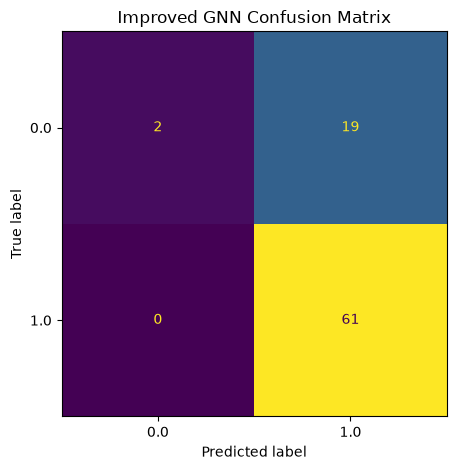

In [298]:
ConfusionMatrixDisplay.from_predictions(
    test_y,
    test_preds,
    colorbar=False
)

plt.title("Improved GNN Confusion Matrix")
plt.tight_layout()
plt.show()

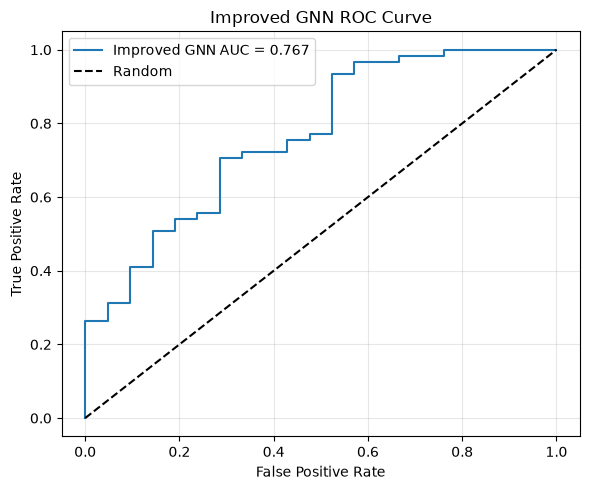

In [299]:
fpr, tpr, _ = roc_curve(test_y, test_probs)
auc = roc_auc_score(test_y, test_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Improved GNN AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Improved GNN ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [300]:
model_small = BetterMolecularGNN(
    num_node_features=num_node_features,
    num_edge_features=num_edge_features,
    num_descriptor_features=num_descriptor_features,
    hidden_dim=64,
    descriptor_hidden_dim=32,
    num_layers=3,
    dropout=0.35
).to(device)

Consider also trying...

hidden_dim = 64 or 128

num_layers = 2, 3, or 4

dropout = 0.1, 0.25, 0.35, 0.5

lr = 0.0005, 0.001, 0.003

weight_decay = 1e-5, 1e-4, 1e-3



In [130]:
seeds = [0, 1, 2, 3, 4, 42, 100]

# Conceptual workflow:
# for seed in seeds:
#     set_seed(seed)
#     initialize model
#     train
#     evaluate
# report mean ± std ROC-AUC

Consider fair comparisons (label for clarity)

LogReg: descriptors only \
LogReg: Morgan fingerprints only \ 
LogReg: Morgan fingerprints + descriptors \
GNN: graph only \
GNN: graph + descriptors 

#### Extend GNN yet again to use improved structure and more input features (SMILES to GNN, then classifier for embedding + Morgan fp + descriptive features)

In [301]:
from rdkit.Chem import AllChem, DataStructs
import numpy as np

def smiles_to_morgan_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return np.zeros(n_bits, dtype=np.float32)

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr


n_bits = 2048

X_fp = np.vstack([
    smiles_to_morgan_fp(smi, radius=2, n_bits=n_bits)
    for smi in valid_df["Drug"]
]).astype(np.float32)

print("Morgan fingerprint matrix shape:", X_fp.shape)
print("Example number of active bits:", int(X_fp[0].sum()))

Morgan fingerprint matrix shape: (406, 2048)
Example number of active bits: 59


In [302]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

use_fingerprint_svd = True
fp_svd_dim = 256

if use_fingerprint_svd:
    fp_svd = TruncatedSVD(
        n_components=fp_svd_dim,
        random_state=42
    )

    X_fp_train_reduced = fp_svd.fit_transform(X_fp[train_idx])
    X_fp_val_reduced = fp_svd.transform(X_fp[val_idx])
    X_fp_test_reduced = fp_svd.transform(X_fp[test_idx])

    # SVD outputs continuous values, so scaling is helpful.
    fp_scaler = StandardScaler()

    X_fp_train_final = fp_scaler.fit_transform(X_fp_train_reduced)
    X_fp_val_final = fp_scaler.transform(X_fp_val_reduced)
    X_fp_test_final = fp_scaler.transform(X_fp_test_reduced)

    X_fp_final = np.zeros(
        (len(valid_df), fp_svd_dim),
        dtype=np.float32
    )

    X_fp_final[train_idx] = X_fp_train_final
    X_fp_final[val_idx] = X_fp_val_final
    X_fp_final[test_idx] = X_fp_test_final

else:
    X_fp_final = X_fp.astype(np.float32)

print("Final fingerprint feature matrix shape:", X_fp_final.shape)

Final fingerprint feature matrix shape: (406, 256)


In [303]:
def smiles_to_graph_with_desc_and_fp(
    smiles,
    y_value,
    descriptor_vector,
    fingerprint_vector
):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    # Atom features
    x = torch.tensor(
        [atom_features(atom) for atom in mol.GetAtoms()],
        dtype=torch.float
    )

    # Edge index and edge attributes
    edge_indices = []
    edge_attrs = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        bf = bond_features(bond)

        edge_indices += [[i, j], [j, i]]
        edge_attrs += [bf, bf]

    if len(edge_indices) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, num_bond_features), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attrs, dtype=torch.float)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=torch.tensor([float(y_value)], dtype=torch.float)
    )

    # Molecule-level features.
    # Shape [1, feature_dim] so PyG batches into [batch_size, feature_dim].
    data.desc = torch.tensor(descriptor_vector, dtype=torch.float).view(1, -1)
    data.fp = torch.tensor(fingerprint_vector, dtype=torch.float).view(1, -1)

    data.smiles = smiles

    return data

In [304]:
gnn_fp_data_list = []

for i in range(len(valid_df)):
    smiles_i = valid_df.iloc[i]["Drug"]
    y_i = int(valid_df.iloc[i]["Y"])
    desc_i = X_desc_scaled[i]
    fp_i = X_fp_final[i]

    data = smiles_to_graph_with_desc_and_fp(
        smiles=smiles_i,
        y_value=y_i,
        descriptor_vector=desc_i,
        fingerprint_vector=fp_i
    )

    gnn_fp_data_list.append(data)

train_data = [gnn_fp_data_list[i] for i in train_idx]
val_data = [gnn_fp_data_list[i] for i in val_idx]
test_data = [gnn_fp_data_list[i] for i in test_idx]

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

num_node_features = gnn_fp_data_list[0].x.shape[1]
num_edge_features = gnn_fp_data_list[0].edge_attr.shape[1]
num_descriptor_features = gnn_fp_data_list[0].desc.shape[1]
num_fp_features = gnn_fp_data_list[0].fp.shape[1]

print("Node feature dim:", num_node_features)
print("Edge feature dim:", num_edge_features)
print("Descriptor feature dim:", num_descriptor_features)
print("Fingerprint feature dim:", num_fp_features)

Node feature dim: 33
Edge feature dim: 10
Descriptor feature dim: 12
Fingerprint feature dim: 256


In [305]:
from torch_geometric.nn import GINEConv, BatchNorm, global_mean_pool, global_max_pool, global_add_pool


class GNNWithDescriptorsAndMorganFP(nn.Module):
    def __init__(
        self,
        num_node_features,
        num_edge_features,
        num_descriptor_features,
        num_fp_features,
        hidden_dim=12,
        descriptor_hidden_dim=8,
        fp_hidden_dim=8,
        num_layers=2,
        dropout=0.3
    ):
        super().__init__()

        self.dropout = dropout

        # -------------------------
        # Graph pathway
        # -------------------------
        self.atom_encoder = nn.Linear(num_node_features, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )

            conv = GINEConv(
                nn=mlp,
                edge_dim=num_edge_features,
                train_eps=True
            )

            self.convs.append(conv)
            self.norms.append(BatchNorm(hidden_dim))

        graph_embedding_dim = hidden_dim * 3  # mean + max + sum pooling

        # -------------------------
        # Descriptor pathway
        # -------------------------
        self.descriptor_mlp = nn.Sequential(
            nn.Linear(num_descriptor_features, descriptor_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # -------------------------
        # Morgan fingerprint pathway
        # -------------------------
        self.fp_mlp = nn.Sequential(
            nn.Linear(num_fp_features, fp_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fp_hidden_dim, fp_hidden_dim),
            nn.ReLU()
        )

        # -------------------------
        # Final classifier
        # -------------------------
        combined_dim = graph_embedding_dim + descriptor_hidden_dim + fp_hidden_dim

        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        batch,
        desc,
        fp,
        return_embedding=False
    ):
        # -------------------------
        # Graph pathway
        # -------------------------
        x = self.atom_encoder(x)

        for conv, norm in zip(self.convs, self.norms):
            residual = x

            x = conv(x, edge_index, edge_attr)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

            x = x + residual

        mean_pool = global_mean_pool(x, batch)
        max_pool = global_max_pool(x, batch)
        sum_pool = global_add_pool(x, batch)

        graph_embedding = torch.cat(
            [mean_pool, max_pool, sum_pool],
            dim=1
        )

        # -------------------------
        # Descriptor pathway
        # -------------------------
        desc_embedding = self.descriptor_mlp(desc)

        # -------------------------
        # Fingerprint pathway
        # -------------------------
        fp_embedding = self.fp_mlp(fp)

        # -------------------------
        # Combine all pathways
        # -------------------------
        combined_embedding = torch.cat(
            [graph_embedding, desc_embedding, fp_embedding],
            dim=1
        )

        logits = self.classifier(combined_embedding).squeeze(-1)

        if return_embedding:
            return logits, graph_embedding, desc_embedding, fp_embedding, combined_embedding

        return logits

In [306]:
def train_one_epoch_hybrid(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        logits = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch,
            batch.desc,
            batch.fp
        )

        y_batch = batch.y.view(-1)

        loss = criterion(logits, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_hybrid(model, loader, criterion=None):
    model.eval()

    all_y = []
    all_probs = []
    all_preds = []
    all_embeddings = []

    total_loss = 0

    for batch in loader:
        batch = batch.to(device)

        logits, graph_emb, desc_emb, fp_emb, combined_emb = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch,
            batch.desc,
            batch.fp,
            return_embedding=True
        )

        y_batch = batch.y.view(-1)

        if criterion is not None:
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * batch.num_graphs

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        all_y.append(y_batch.cpu())
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_embeddings.append(combined_emb.cpu())

    all_y = torch.cat(all_y).numpy()
    all_probs = torch.cat(all_probs).numpy()
    all_preds = torch.cat(all_preds).numpy()
    all_embeddings = torch.cat(all_embeddings).numpy()

    metrics = {}

    if criterion is not None:
        metrics["loss"] = total_loss / len(loader.dataset)

    metrics["accuracy"] = accuracy_score(all_y, all_preds)

    if len(np.unique(all_y)) > 1:
        metrics["roc_auc"] = roc_auc_score(all_y, all_probs)
        metrics["average_precision"] = average_precision_score(all_y, all_probs)
    else:
        metrics["roc_auc"] = np.nan
        metrics["average_precision"] = np.nan

    return {
        "y": all_y,
        "probs": all_probs,
        "preds": all_preds,
        "embeddings": all_embeddings,
        "metrics": metrics
    }

In [307]:
set_seed(42)

hybrid_model = GNNWithDescriptorsAndMorganFP(
    num_node_features=num_node_features,
    num_edge_features=num_edge_features,
    num_descriptor_features=num_descriptor_features,
    num_fp_features=num_fp_features,
    hidden_dim=16,
    descriptor_hidden_dim=8,
    fp_hidden_dim=8,
    num_layers=3,
    dropout=0.3
).to(device)

train_labels = labels[train_idx]
num_pos = train_labels.sum()
num_neg = len(train_labels) - num_pos

pos_weight = torch.tensor(
    [num_neg / max(num_pos, 1)],
    dtype=torch.float
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    hybrid_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=10
)

hybrid_model

GNNWithDescriptorsAndMorganFP(
  (atom_encoder): Linear(in_features=33, out_features=16, bias=True)
  (convs): ModuleList(
    (0-2): 3 x GINEConv(nn=Sequential(
      (0): Linear(in_features=16, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=16, bias=True)
    ))
  )
  (norms): ModuleList(
    (0-2): 3 x BatchNorm(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (descriptor_mlp): Sequential(
    (0): Linear(in_features=12, out_features=8, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (fp_mlp): Sequential(
    (0): Linear(in_features=256, out_features=8, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=8, out_features=8, bias=True)
    (4): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features

In [308]:
import copy

history = []

best_val_auc = -np.inf
best_state = copy.deepcopy(hybrid_model.state_dict())

patience = 500
epochs_without_improvement = 0

num_epochs = 100

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch_hybrid(
        hybrid_model,
        train_loader,
        optimizer,
        criterion
    )

    val_results = evaluate_hybrid(
        hybrid_model,
        val_loader,
        criterion
    )

    val_metrics = val_results["metrics"]
    val_auc = val_metrics["roc_auc"]

    scheduler.step(val_auc)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_average_precision": val_metrics["average_precision"],
        "lr": optimizer.param_groups[0]["lr"]
    })

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = copy.deepcopy(hybrid_model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 1 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val AUC: {val_auc:.4f} | "
            f"Val AP: {val_metrics['average_precision']:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.6f}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

history_df = pd.DataFrame(history)

hybrid_model.load_state_dict(best_state)

print(f"Best validation ROC-AUC: {best_val_auc:.4f}")

Epoch 001 | Train Loss: 0.3675 | Val AUC: 0.7372 | Val AP: 0.9079 | LR: 0.001000
Epoch 002 | Train Loss: 0.3554 | Val AUC: 0.7334 | Val AP: 0.9004 | LR: 0.001000
Epoch 003 | Train Loss: 0.3392 | Val AUC: 0.7181 | Val AP: 0.8848 | LR: 0.001000
Epoch 004 | Train Loss: 0.3555 | Val AUC: 0.6722 | Val AP: 0.8663 | LR: 0.001000
Epoch 005 | Train Loss: 0.3393 | Val AUC: 0.6607 | Val AP: 0.8681 | LR: 0.001000
Epoch 006 | Train Loss: 0.3426 | Val AUC: 0.7577 | Val AP: 0.9120 | LR: 0.001000
Epoch 007 | Train Loss: 0.3486 | Val AUC: 0.6122 | Val AP: 0.8105 | LR: 0.001000
Epoch 008 | Train Loss: 0.3267 | Val AUC: 0.7385 | Val AP: 0.8848 | LR: 0.001000
Epoch 009 | Train Loss: 0.3314 | Val AUC: 0.6901 | Val AP: 0.8396 | LR: 0.001000
Epoch 010 | Train Loss: 0.3242 | Val AUC: 0.7449 | Val AP: 0.8749 | LR: 0.001000
Epoch 011 | Train Loss: 0.3200 | Val AUC: 0.7156 | Val AP: 0.8647 | LR: 0.001000
Epoch 012 | Train Loss: 0.3064 | Val AUC: 0.6952 | Val AP: 0.8486 | LR: 0.001000
Epoch 013 | Train Loss: 0.30

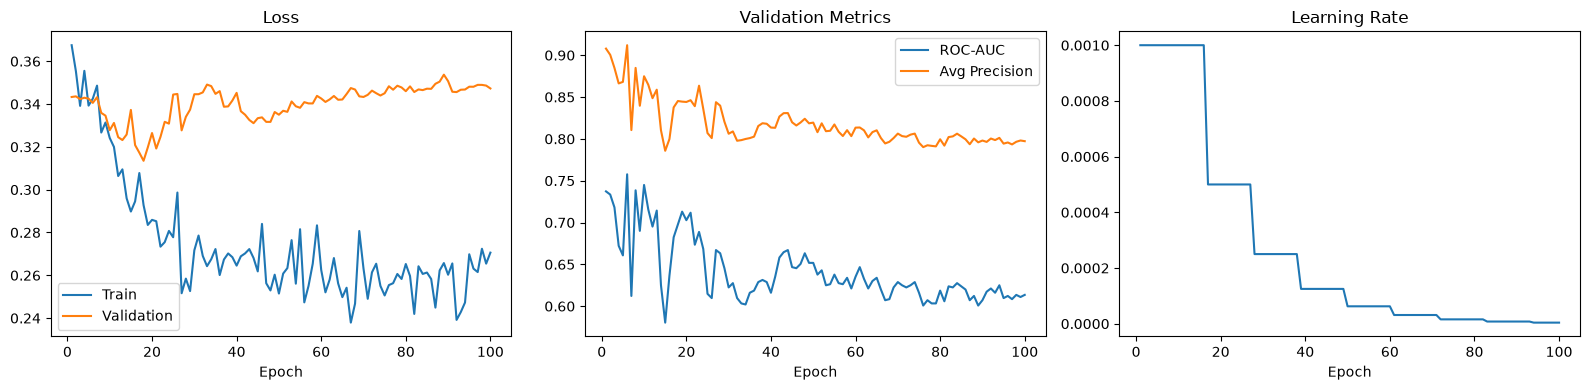

In [309]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_roc_auc"], label="ROC-AUC")
axes[1].plot(history_df["epoch"], history_df["val_average_precision"], label="Avg Precision")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["lr"])
axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

In [310]:
hybrid_test_results = evaluate_hybrid(
    hybrid_model,
    test_loader,
    criterion
)

hybrid_y = hybrid_test_results["y"]
hybrid_probs = hybrid_test_results["probs"]
hybrid_preds = hybrid_test_results["preds"]

print("Hybrid GNN + descriptors + Morgan fingerprint test metrics")
for k, v in hybrid_test_results["metrics"].items():
    print(f"{k}: {v:.3f}")

Hybrid GNN + descriptors + Morgan fingerprint test metrics
loss: 0.337
accuracy: 0.756
roc_auc: 0.732
average_precision: 0.882


In [152]:
# ### Consider comparing to NN classifier on Morgan Fingerprint alone 

# class FPDescriptorMLP(nn.Module):
#     def __init__(
#         self,
#         num_fp_features,
#         num_descriptor_features,
#         hidden_dim=128,
#         dropout=0.3
#     ):
#         super().__init__()

#         input_dim = num_fp_features + num_descriptor_features

#         self.net = nn.Sequential(
#             nn.Linear(input_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(hidden_dim, hidden_dim // 2),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(hidden_dim // 2, 1)
#         )

#     def forward(self, fp, desc):
#         x = torch.cat([fp, desc], dim=1)
#         return self.net(x).squeeze(-1)